In [15]:
from platform import python_version
print(python_version())

3.12.12


### This notebook is an study over the paper "Spatial Transcriptomics data of developmental neural crest".


> The code is written primarily in Python and was supported by Claude/Opus 5.  
> There are a few CLIs in R and Bash.  

[DOI: https://doi.org/10.1038/s41588-025-02352-6](https://www.science.org/doi/10.1126/science.aas9536?referrer=https%3A%2F%2Fwww.google.com%2F#sec-10)



![neural_crest_dev](../pictures/neural_crest_dev.jpeg)


And the published innervation result reads: RNA velocity and pseudotime analyses confirmed a `fork-like transition from early SCPs` towards two parallel trajectories of `neuronal-chromaffin` and `glial cell` lineages. The fork is neuronal-chromaffin versus glial — not chromaffin versus neuronal. 

Schwann Cell Precursors (SCPs) are embryonic glial progenitor cells derived from neural crest cells that migrate along growing peripheral nerves. While traditionally thought to only form mature myelinating and non-myelinating Schwann cells, SCPs are now recognized as highly multipotent cells capable of generating diverse cell types like neurons, melanocytes, and endocrine cells.


### Data storage

???

Worth remembering the asymmetry: 

if you launch a kernel without the conda env active, the helper adds $R_HOME/bin (R-only, safe). If you launch with it active, conda's bin is already ahead and carries a python — harmless as long as .venv/bin precedes it, which check_r_stack doesn't verify. shutil.which("python") is the one-line check if a subprocess ever behaves oddly.

In [16]:
# os.environ["R_HOME"] = "/home/flavio/miniforge3/envs/renv/lib/R"
# os.environ["R_LIBS_USER"] = "/home/flavio/miniforge3/envs/renv/lib/R/library"

In [17]:
import os, sys, shutil
from pathlib import Path

SRC = next(p / "src" for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "libs").is_dir())
sys.path.insert(0, str(SRC))

from libs.paths import PROJ, H5AD, TABLES, FIGURES      # no chdir needed

#  R_HOME, LD_LIBRARY_PATH." LD_LIBRARY_PATH is not needed — your rpy2 was linked with an rpath, and setting it from inside Python has no effect anyway since the loader reads it at process start. 
# # The second requirement is R on PATH, for scFates' shutil.which("R") check. So: R_HOME + PATH.
# os.environ["R_HOME"] = "/home/flavio/miniforge3/envs/renv/lib/R"
# os.environ["R_LIBS_USER"] = "/home/flavio/miniforge3/envs/renv/lib/R/library"
from libs.run_scfates import preprocess, fit_curve      # sets R_HOME + PATH, then imports scFates
import rpy2.situation as s

print("python :", sys.executable)
print("R      :", shutil.which("R"), "| R_HOME:", os.environ.get("R_HOME"))
print("R in rpy2", s.get_r_home())
PROJ, H5AD, TABLES, FIGURES

python : /home/flavio/uv/neural_crest/.venv/bin/python
R      : /home/flavio/miniforge3/envs/renv/bin/R | R_HOME: /home/flavio/miniforge3/envs/renv/lib/R
R in rpy2 /home/flavio/miniforge3/envs/renv/lib/R


(PosixPath('/home/flavio/uv/neural_crest'),
 PosixPath('/home/flavio/uv/neural_crest/data/h5ad'),
 PosixPath('/home/flavio/uv/neural_crest/results/tables'),
 PosixPath('/home/flavio/uv/neural_crest/results/figures'))

In [18]:
import importlib
_f = importlib.import_module("scFates.tools.test_association")
print("R stack:", all(not isinstance(getattr(_f, module), str)
                      for module in ("Rpy2", "R", "rstats", "rmgcv", "Formula")))

R stack: True


In [19]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

from scipy.stats import spearmanr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/neural_crest")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, str(ROOT_SRC))

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir

root_figure = create_dir(ROOT0, "pictures")
root_results = create_dir(ROOT0, "results")
root_tables = create_dir(root_results, "tables")

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/neural_crest
ROOT_SRC added: /home/flavio/uv/neural_crest/src


In [20]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

ROOT0_DATA = create_dir(ROOT0, "data")
root_colab = create_dir(ROOT0_DATA, "colab")

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']

case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']


### Scanpy Introduction

https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#

In [21]:
# Core scverse libraries
from __future__ import annotations

# import anndata as ad

# Pooch is a Python library that can manage data by downloading files from a server (only when needed) and storing them locally in a data cache 
# import pooch
import scanpy as sc
import squidpy as sq
import importlib

# scanpy 1.12.4 | squidpy 1.8.3 | anndata 0.13.3.post0
# import anndata
import json

importlib.metadata.version("scanpy"), importlib.metadata.version("squidpy"), importlib.metadata.version("anndata")


('1.12.4', '1.8.3', '0.13.4')

In [22]:
sc.set_figure_params(dpi=120, facecolor="white")

### Getting data

#### All single-cell RNA-seq datasets

- have been deposited in the GEO under accession code GSE129114. 

#### Processed data, code, supplementary materials, and interactive views of datasets 

- can be accessed on the authors’ website: http://pklab.med.harvard.edu/ruslan/neural.crest.html. 

anndata: https://anndata.scverse.org/en/stable/tutorials/notebooks/getting-started.html

In [23]:
ROOT0_DATA

PosixPath('/home/flavio/uv/neural_crest/data')

In [24]:
root_h5 = create_dir(ROOT0_DATA, "h5ad")
root_h5, H5AD

(PosixPath('/home/flavio/uv/neural_crest/data/h5ad'),
 PosixPath('/home/flavio/uv/neural_crest/data/h5ad'))

In [25]:
os.listdir(root_h5)

['innervation_selection_scfates.h5ad',
 'innervation.h5ad',
 'vfd40245c_innervation_selection_scfates.h5ad']

In [26]:
root_meta = create_dir(ROOT0_DATA, "meta")
root_results = create_dir(ROOT0_DATA, 'results')
os.listdir(root_results)

['.~lock.innervation_celltype_markers.tsv#',
 'innervation_celltype_markers.tsv',
 'innervation_tsd_by_celltype.tsv']

In [27]:
root_bundles = create_dir(ROOT0_DATA, "bundles")
root_bundles_in = create_dir(root_bundles, "IN_sel")
os.listdir(root_bundles_in)

['features.csv',
 'metadata.csv',
 'reduction_umap_subset.csv',
 'counts.mtx',
 'reduction_umap_subset_3d.csv',
 'reduction_harmony_subset.csv',
 'manifest.json',
 'reduction_umap_oi.csv',
 'reduction_umap_df.csv',
 'reduction_pca.csv',
 'reduction_harmony_oi.csv',
 'barcodes.csv']

In [28]:
from libs.assemble_h5ad import assemble

adata = assemble(root_bundles_in, root_h5 / "innervation.h5ad")   # h5ad written to my workspace (grant is read-only)

innervation.rds: 1106 cells x 31136 genes | layer=counts | integer counts=True | obsm=['X_harmony_oi', 'X_harmony_subset', 'X_pca', 'X_umap_df', 'X_umap_oi', 'X_umap_subset', 'X_umap_subset_3d'] | obs cols=30
wrote /home/flavio/uv/neural_crest/data/h5ad/innervation.h5ad


In [29]:
print("\nobs columns:")
for c in adata.obs.columns:
    s = adata.obs[c]
    nun = s.nunique(dropna=True)
    na = int(s.isna().sum())
    head = list(s.dropna().unique()[:6]) if nun <= 40 else f"{s.min()}..{s.max()}"
    print(f"  {c:32s} n={nun:4d} NA={na:5d}  {head}")


obs columns:
  orig.ident                       n=  15 NA=    0  ['10X127', '10X142', '10X151', '10X158', '10X166', '10X246']
  nCount_RNA                       n=1081 NA=    0  356..255699
  nFeature_RNA                     n=1054 NA=    0  266..13929
  sampleID                         n=  21 NA=    0  ['TenX127_1', 'TenX142_1', 'TenX151_3', 'TenX158_1', 'TenX158_2', 'TenX166_1']
  DoubletFlag                      n=   2 NA=    0  [np.int64(1), np.int64(2)]
  DoubletScore                     n= 153 NA=    0  0.0..0.555555582046509
  DropletClass                     n=   7 NA=    0  [np.int64(0), np.int64(5), np.int64(4), np.int64(1), np.int64(3), np.int64(2)]
  age                              n=  11 NA=    0  [np.float64(9.0), np.float64(8.5), np.float64(6.0), np.float64(8.0), np.float64(13.25), np.float64(14.0)]
  age_round_up                     n=   7 NA=    0  [np.int64(9), np.int64(6), np.int64(8), np.int64(14), np.int64(12), np.int64(10)]
  age_round_down                   n= 

In [30]:
ct = adata.obs["cell.types"].astype(str)

";".join(ct[:10]) + '...'

'Chrom_C;IN_excl_1;Aut_Neu_1;Chrom_C;Aut_Neu_1;SCP_1;IN_excl_2;IN_excl_3;SCP_2;IN_excl_2...'

In [31]:
adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampleID', 'DoubletFlag', 'DoubletScore',
       'DropletClass', 'age', 'age_round_up', 'age_round_down', 'percent_ribo', 'percent_mito',
       'percent_hb', 'percent_hsp', 'apoptotic_maybe', 'S.Score', 'G2M.Score', 'Phase',
       'clusters_louvain_unfilt', 'clusters_louvain_dataset', 'pANN', 'DF.classifications',
       'clusters_louvain_oi', 'age_heart', 'age_dataset', 'high_level_clusters',
       'high_level_clusters_removed', 'cell.types', 'age_groups', 'clusters_subset'],
      dtype='object')

In [32]:
adata.obs.head(3).T

,10X127_1:ACACCAAAGCCACGTC,10X127_1:ACACCGGAGATCTGCT,10X127_1:ACAGCTAAGGCAATTA
orig.ident,10X127,10X127,10X127
nCount_RNA,1037,3639,4473
nFeature_RNA,784,1977,2451
sampleID,TenX127_1,TenX127_1,TenX127_1
DoubletFlag,1,1,1
DoubletScore,0.0,0.304,0.143
DropletClass,0,0,0
age,9.0,9.0,9.0
age_round_up,9,9,9
age_round_down,9,9,9


In [33]:
tab = (pd.crosstab(ct, adata.obs["clusters_subset"])
         .pipe(lambda d: d.loc[d.sum(1).sort_values(ascending=False).index]))

tab

clusters_subset,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
cell.types,,,,,,,,,,,,,,,,,,,
SCP_5,0,0,0,0,0,0,0,195,0,0,0,0,0,0,0,0,0,0,0
SCP_1,0,0,0,168,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Aut_Neu_1,0,0,145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
SCP_2,0,0,0,0,0,0,80,0,0,0,0,0,0,0,0,0,0,0,0
SCP_4,0,0,0,0,0,0,0,0,0,0,72,0,0,0,0,0,0,0,0
Aut_Neu_2,0,0,0,0,0,0,0,0,0,0,0,0,69,0,0,0,0,0,0
IN_excl_1,0,59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
IN_excl_6,0,0,0,0,0,0,0,0,0,0,0,0,0,41,0,0,0,0,0
Chrom_C,41,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [34]:
counts = ct.value_counts()
print("cell.types (n cells), and the clusters_subset id each maps to:")
for t, n in counts.items():
    ids = tab.columns[tab.loc[t] > 0].tolist()
    print(f"  {t:12s} {n:5d}  -> clusters_subset {ids}")
excl = ct.str.startswith("IN_excl")
print(f"\nIN_excl* cells: {int(excl.sum())} | remaining: {int((~excl).sum())} of {adata.n_obs}")
print("\nage_groups x excluded:\n", pd.crosstab(adata.obs['age_groups'], excl).to_string())
print("\nPENK present:", "PENK" in adata.var_names)

cell.types (n cells), and the clusters_subset id each maps to:
  SCP_5          195  -> clusters_subset [8]
  SCP_1          168  -> clusters_subset [4]
  Aut_Neu_1      145  -> clusters_subset [3]
  SCP_2           80  -> clusters_subset [7]
  SCP_4           72  -> clusters_subset [11]
  Aut_Neu_2       69  -> clusters_subset [13]
  IN_excl_1       59  -> clusters_subset [2]
  Chrom_C         41  -> clusters_subset [1]
  IN_excl_6       41  -> clusters_subset [14]
  SCP_3           38  -> clusters_subset [12]
  Bridge_state    34  -> clusters_subset [17]
  IN_excl_2       33  -> clusters_subset [5]
  My_SC           28  -> clusters_subset [19]
  IN_excl_5       23  -> clusters_subset [10]
  IN_excl_9       19  -> clusters_subset [18]
  IN_excl_4       17  -> clusters_subset [9]
  IN_excl_7       15  -> clusters_subset [15]
  IN_excl_8       15  -> clusters_subset [16]
  IN_excl_3       14  -> clusters_subset [6]

IN_excl* cells: 236 | remaining: 870 of 1106

age_groups x excluded:
 c

In [35]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'python_version', '_i2', '_i3', 'os', 'sys', 'shutil', 'Path', 'SRC', 'PROJ', 'H5AD', 'TABLES', 'FIGURES', 'preprocess', 'fit_curve', 's', '_3', '_i4', 'importlib', '_f', '_i5', 'yaml', 'load_dotenv', 'np', 'pd', 'sns', 'spearmanr', 'mpl', 'plt', 'gridspec', 'ROOT0', 'ROOT_SRC', '_i6', '_i7', '_i8', '_8', '_i9', '_i10', '_i11', 'create_dir', 'root_figure', 'root_results', 'root_tables', 'display', 'HTML', 'file', 'dic_yml', '_i12', 'email', 'i_project', 'project_list', 'n', 'project', 's_project_list', 's_project', 'ROOT0_DATA', 'root_colab', 'CONTEXT_DISESE', 'context_disease', 'gene_protein', 's_omics', 'has_age', 'has_gender', 'LFC_cut_inf', 's_pathw_enrichm_method', 'ptw_min_num_of_degs_cut', 'pval_pathway_cutoff', 'fdr_pathway_cutoff', 'n

### Rebuild the state in your notebook

In [36]:
from libs.run_scfates import preprocess, fit_curve, plot_trajectory, test_association, _ensure_r_home

_ensure_r_home()

'/home/flavio/miniforge3/envs/renv/lib/R'

In [37]:
sel = adata[~adata.obs["cell.types"].astype(str).str.startswith("IN_excl")].copy()
sel.obs["cell.types"] = sel.obs["cell.types"].astype(str).astype("category")   # drop empty levels

IN = preprocess(sel, n_top_genes=5000, n_neighbors=25, layer="counts")         # 870 x 5000
fit_curve(IN, root_gene="PENK", nodes=30, n_map=100, n_jobs=15, seed=42)       # published recipe

/home/flavio/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


preprocessed: 870 cells x 5000 HVGs
inferring a principal curve --> parameters used 
    30 principal points, mu = 0.1, lambda = 0.01
    finished (0:00:00) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.
automatic root selection using PENK values
node 12 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:09<00:00, 10.20it/s]
    finished (0:00:09) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones

AnnData object with n_obs × n_vars = 870 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampleID', 'DoubletFlag', 'DoubletScore', 'DropletClass', 'age', 'age_round_up', 'age_round_down', 'percent_ribo', 'percent_mito', 'percent_hb', 'percent_hsp', 'apoptotic_maybe', 'S.Score', 'G2M.Score', 'Phase', 'clusters_louvain_unfilt', 'clusters_louvain_dataset', 'pANN', 'DF.classifications', 'clusters_louvain_oi', 'age_heart', 'age_dataset', 'high_level_clusters', 'high_level_clusters_removed', 'cell.types', 'age_groups', 'clusters_subset', 't', 'seg', 'edge', 't_sd', 'milestones'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'graph', 'epg', 'pseudotime_list', 'milestones_colors', 'seg_colors'
    obsm: 'X_harmony_oi', 'X_harmony_subset', 'X_pca', 'X_umap_df', 'X_umap_oi', 'X_umap_subset', 'X_umap_subset_3d', 'X_R'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None 

In [38]:
IN

AnnData object with n_obs × n_vars = 870 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampleID', 'DoubletFlag', 'DoubletScore', 'DropletClass', 'age', 'age_round_up', 'age_round_down', 'percent_ribo', 'percent_mito', 'percent_hb', 'percent_hsp', 'apoptotic_maybe', 'S.Score', 'G2M.Score', 'Phase', 'clusters_louvain_unfilt', 'clusters_louvain_dataset', 'pANN', 'DF.classifications', 'clusters_louvain_oi', 'age_heart', 'age_dataset', 'high_level_clusters', 'high_level_clusters_removed', 'cell.types', 'age_groups', 'clusters_subset', 't', 'seg', 'edge', 't_sd', 'milestones'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'graph', 'epg', 'pseudotime_list', 'milestones_colors', 'seg_colors'
    obsm: 'X_harmony_oi', 'X_harmony_subset', 'X_pca', 'X_umap_df', 'X_umap_oi', 'X_umap_subset', 'X_umap_subset_3d', 'X_R'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None 

Object looks complete: 35 obs columns = your original 30 plus the four scFates outputs (t, seg, edge, t_sd) and milestones. What they mean:

- t — pseudotime, averaged over the 100 mappings
- t_sd — its standard deviation across those mappings (1.16, 0.73, 1.58 here, on a ~95-unit axis, so tightly determined)
- seg — which branch of the principal graph the cell sits on
- edge — the pair of principal points it falls between (7|10, 25|1)
- milestones — nearest milestone node; all three show 12, which is the root node PENK selected

Your first three cells illustrate the internal-root problem concretely: 
1. two Chrom_C and one Aut_Neu_1 
  - all terminally differentiated types — sit at t = 8.76, 10.40, 6.79, i.e. essentially at the origin. 
  - That's the signature of rooting mid-curve: pseudotime measures distance from node 12 in both directions, so a differentiated population ends up at the start.


In [39]:
print(IN.obs.shape)

IN.obs.head(3).T

(870, 35)


,10X127_1:ACACCAAAGCCACGTC,10X127_1:ACAGCTAAGGCAATTA,10X127_1:ACGATGTAGGGCATGT
orig.ident,10X127,10X127,10X127
nCount_RNA,1037,4473,929
nFeature_RNA,784,2451,711
sampleID,TenX127_1,TenX127_1,TenX127_1
DoubletFlag,1,1,1
DoubletScore,0.0,0.143,0.071
DropletClass,0,0,0
age,9.0,9.0,9.0
age_round_up,9,9,9
age_round_down,9,9,9


Two checks worth running on your object:

In [40]:
# print(pd.crosstab(IN.obs["cell.types"], IN.obs["seg"]))          # which types share each branch
print(IN.uns["graph"]["pp_seg"])                                  # from/to nodes per branch
print("root:", IN.uns["graph"]["root"], "tips:", IN.uns["graph"]["tips"])   # root among tips?

pd.crosstab(IN.obs["cell.types"], IN.obs["seg"])

   n  from  to       d
1  1    12   0  96.936
2  2    12   2  34.546
root: 12 tips: [0 2]


seg,1,2
cell.types,,
Aut_Neu_1,49,96
Aut_Neu_2,29,40
Bridge_state,33,1
Chrom_C,23,18
My_SC,27,1
SCP_1,168,0
SCP_2,80,0
SCP_3,38,0
SCP_4,72,0


That explains everything. PENK marks the chromaffin end, not the progenitor end:

| type	| n	| PENK mean	|  % expressing | 
|-------|---|-----------|---------------|
| Chrom_C	| 41	| 0.88	| 65.9 | 
| Aut_Neu_1	| 145	| 0.13	| 15.9 | 
| SCP_1	| 168	| 0.02	| 2.4 | 
| SCP_5	| 195	| 0.00	| 2.6 | 
| Bridge_state	| 34	| 0.00	| 0.0 | 


scf.tl.root(adata, "PENK") picks the node with highest mean PENK — so it roots the trajectory in the chromaffin population, which sits between the two tips. Hence node 12 internal, tips [0, 2], and two branches radiating out:


1. seg 1:  12 → 0   d = 96.9   holds all 553 SCPs (plus neurons lying between root and SCP tip)
2. seg 2:  12 → 2   d = 34.5   holds the neuronal tip
3. 96.9 + 34.5 = 131.5, the full graph length — and my SCP-tip-rooted fit spans 129.8, i.e. the same single axis traversed end to end. 
- Rooting at tip 0 merges these two branches into one monotone segment.

Two consequences visible in your crosstab that matter for interpretation:

1. Pseudotime runs backwards on segment
  SCPs sit at high t there (up to 96.9) while chromaffin and neurons sit near t = 0. So on the larger branch, increasing pseudotime means progenitor-ward.
2. The neuronal types are split across both branches — Aut_Neu_1 49/96, Aut_Neu_2 29/40, Chrom_C 23/18. Any per-segment trend analysis on this rooting compares the same cell type against itself in two opposite directions.

So the published recipe is reproducible but its root choice is a marker-selection artifact: PENK is a terminal marker being used as a progenitor marker. Rooting at the SCP tip is the defensible version, and it's what the saved fit and all the module analysis use.

That closes the last open question in the analysis. Ready to assemble the methods note — version deviations, the root-choice reasoning per compartment, and links to every figure and table — unless you want anything else checked first.

### Then the tip-rooted variant, using the helper rather than a hard-coded node

- SCP ~ Schwann Cell Precursors, which are nerve-associated embryonic progenitor cells that display broad multipotent potential.

In [41]:
import scFates as scf


def progenitor_tip(adata, progenitor_prefix="SCP", label_key="cell.types", n_cells=30):
    """Return the tip node whose closest cells are richest in `progenitor_prefix`."""
    R = np.asarray(adata.obsm["X_R"])            # soft assignment, cells x nodes
    labs = adata.obs[label_key].astype(str).values
    out = {}
    for tip in map(int, adata.uns["graph"]["tips"]):
        near = np.argsort(R[:, tip])[::-1][:n_cells]
        out[tip] = float(np.mean([l.startswith(progenitor_prefix) for l in labs[near]]))
    return max(out, key=out.get), out

IN_tip = IN.copy()
del IN_tip.uns["graph"]["root"]
tip, frac = progenitor_tip(IN)                   # {0: 0.27, 2: 0.0} -> tip 0
scf.tl.root(IN_tip, tip)
scf.tl.pseudotime(IN_tip, n_jobs=10, n_map=100, seed=42)

node 0 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:10<00:00,  9.35it/s]
    finished (0:00:10) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


In [42]:
# assert {'IN', 'IN_tip', 'pca', 'ct', 'order', 'pal'} <= globals().keys()

### The plotting variables were just locals in my figure cell:

In [43]:
pca   = IN.obsm["X_pca"][:, :2]
ct    = IN.obs["cell.types"].astype(str)
order = ["SCP_1","SCP_2","SCP_3","SCP_4","SCP_5","My_SC","Bridge_state","Chrom_C","Aut_Neu_1","Aut_Neu_2"]
pal   = dict(zip(order, plt.get_cmap("tab10")(np.linspace(0, 1, 10))))

### Important

Two things worth knowing when you run it. 

- scf.tl.root refuses to overwrite an existing root, hence the del 
- and if you skip the .copy() you'll overwrite the PENK fit and lose the comparison. 

- And that 27% is not a commanding majority: 
  - the cells nearest tip 0 are a mix of SCPs and Bridge_state, which is the same signal that makes me think a tree is the better model here.

Everything above is also saved in innervation_pseudotime.csv and innervation_selection_scfates.h5ad, so you can skip the refit entirely — sc.read_h5ad on that object gives you IN with both pseudotimes already in obs.

In [44]:
summ = pd.DataFrame({
    "n": IN.obs["cell.types"].value_counts(),
    "t_PENK": IN.obs.groupby("cell.types", observed=True)["t"].mean(),
    "t_sd_PENK": IN.obs.groupby("cell.types", observed=True)["t_sd"].median(),
    "t_SCPtip": IN_tip.obs.groupby("cell.types", observed=True)["t"].mean(),
    "t_sd_SCPtip": IN_tip.obs.groupby("cell.types", observed=True)["t_sd"].median(),
}).sort_values("t_SCPtip")

summ

,n,t_PENK,t_sd_PENK,t_SCPtip,t_sd_SCPtip
cell.types,,,,,
Bridge_state,34,57.364,1.157,39.572,1.157
SCP_1,168,49.477,1.026,47.459,1.026
SCP_3,38,47.145,1.252,49.791,1.252
SCP_5,195,47.090,0.709,49.845,0.709
My_SC,28,46.514,0.837,50.422,0.837
SCP_4,72,43.014,0.926,53.921,0.926
SCP_2,80,42.936,1.321,53.999,1.321
Chrom_C,41,26.974,1.241,78.148,1.241
Aut_Neu_1,145,31.414,0.996,90.854,0.996


In [45]:
import warnings

warnings.simplefilter("ignore")

root_claude = Path("/home/flavio/.claude-science")
root_artifact = Path("orgs/abb023bb-bd59-418e-bf97-0ebfba525efa/artifacts/proj_c74c86fe51af/71854aa8-1956-4fe8-ace3-00fae28123e6/")
# moved to root_h5
fname_h5 = "vfd40245c_innervation_selection_scfates.h5ad"
fname = "innervation_celltype_markers.tsv"

filename = root_results / fname

if not filename.exists():
    IN = sc.read_h5ad(root_h5 / fname_h5)

    sc.tl.rank_genes_groups(IN, "cell.types", method="wilcoxon", use_raw=True, n_genes=10)
    mk = pd.DataFrame({g: [IN.uns["rank_genes_groups"]["names"][g][i] for i in range(8)]
                    for g in IN.obs["cell.types"].cat.categories})
    tab = pd.DataFrame({
        "n": IN.obs["cell.types"].value_counts(),
        "t_SCPtip": IN.obs.groupby("cell.types", observed=True)["t_SCPtip_root"].mean().round(1),
        "top_markers": {c: ", ".join(mk[c][:6]) for c in mk.columns},
    }).sort_values("t_SCPtip")


    tab.reset_index(inplace=True)
    cols = list(tab.columns)
    cols[0] = 'cell_type'
    tab.columns = cols

    tab.to_csv(root_results / fname, sep='\t', index=False)
else:
    tab = pd.read_csv(filename, sep='\t')

print(tab.shape)
tab

(10, 4)


,cell_type,n,t_SCPtip,top_markers
0,Bridge_state,34,39.6,"ASCL1, TBX2, LINC00682, TLX2, ZNF704, DPYD"
1,SCP_1,168,47.5,"PLS3, MEF2C, POSTN, PTPRJ, ADAMTSL1, IL1RAPL2"
2,SCP_3,38,49.8,"HSP90AB1, HSP90AA1, HSPA1B, JUND, CREB5, PEAK1"
3,SCP_5,195,49.8,"SPARC, COL1A2, RELN, COL1A1, GFRA3, PLEKHA4"
4,My_SC,28,50.4,"COL3A1, PMP22, MBP, COL1A1, COL1A2, S100B"
5,SCP_4,72,53.9,"TRPM3, NRXN3, MIR99AHG, OLFML2A, APP, PLP1"
6,SCP_2,80,54.0,"LRRC7, PLEKHG1, MEF2C, SOX5, ANXA1, PTPRZ1"
7,Chrom_C,41,78.1,"DLK1, CHGB, FAM162B, NDUFA4L2, RAMP1, RGS5"
8,Aut_Neu_1,145,90.9,"EML5, SYT1, ELAVL4, ARHGEF28, CADPS, SLIT3"
9,Aut_Neu_2,69,99.7,"TUBB2B, TUBB3, TUBA1A, STMN2, TMSB10, TUBB"


#### chromaffin transition 

Chromaffin transition primarily refers to the specialized cellular process where nerve-associated progenitor cells differentiate into neuroendocrine chromaffin cells within the adrenal medulla.

[Developmental heterogeneity of embryonic neuroendocrine chromaffin cells and their maturation dynamics - 2022](https://www.nature.com/articles/s41467-022-30438-w)  
[Serotonin limits generation of chromaffin cells during adrenal organ development - 2022](https://www.frontiersin.org/journals/endocrinology/articles/10.3389/fendo.2022.1020000/full)  


#### The Developmental Transition (Progenitor to Neuroendocrine)

For decades, textbooks taught that chromaffin cells derived directly from migrating neural crest cells. 

Modern single-cell transcriptomics has updated this model, revealing a precise transitional pathway:

1. Schwann Cell Precursors (SCPs): Progenitor cells migrate along preganglionic sympathetic nerves to reach the embryonic adrenal gland.
2. The "Bridge" State: Upon arriving at the adrenal primordium, SCPs transition into a short-lived, transient cell population known as "bridge" cells (frequently marked by the expression of the Htr3a gene).
3. Mature Chromaffin Cells: The bridge cells rapidly complete their transition into fully specialized chromaffin cells. Driven by core transcription factors like Ascl1 and Phox2b, they stop expressing glial markers, lose their ability to grow long axons, and instead acquire a secretory phenotype capable of packaging catecholamines into large dense-core granules.

#### SCP_1–5 — Schwann cell precursors (553 cells, 64% of the compartment). 
Neural crest–derived glial precursors that migrate along developing nerves and remain multipotent: they generate Schwann cells, and via the bridge state chromaffin cells. The five subsets are states rather than a maturation series. SCP_5 and SCP_1 carry matrix programs (COL1A1/COL1A2, SPARC, POSTN), with GFRA3 in SCP_5 a genuine neural-crest/SCP receptor. SCP_4 is the most glial-committed — PLP1 is the canonical Schwann-lineage myelin proteolipid, alongside NRXN3. SCP_2 carries SOX5 and PTPRZ1, both glial-progenitor associated.

#### SCP_3 ???
Deserves scepticism. Its entire top-ranked signature is heat-shock and stress response — HSP90AB1, HSP90AA1, HSPA1B, JUND. That's a dissociation-stress phenotype, not a cell identity, and its 38 cells probably shouldn't be read as a biological state at all. I'd exclude it from any pseudotime interpretation.

#### My_SC — myelinating Schwann cells (28). 
MBP (myelin basic protein), PMP22, S100B: the terminal glial fate. Only 28 cells because myelination barely starts before PCW 14.

#### Bridge_state (34). 
The SCP → chromaffin transition, described by Furlan et al. in mouse adrenal medulla. ASCL1 is the proneural transcription factor that drives sympathoadrenal specification, with TBX2 and TLX2 alongside it. This cluster is the mechanistic link underpinning the paper's chromaffin claim.

#### Chrom_C — chromaffin cells (41). 
CHGB (chromogranin B, the secretory-granule protein that defines chromaffin identity) plus DLK1 and NDUFA4L2. The abstract presents these as the first spatial account of chromaffin cells in the fetal human heart.

#### Aut_Neu_1 (145) — differentiated autonomic neurons. 
SYT1 (synaptotagmin-1, synaptic vesicle), ELAVL4 (HuD, neuron-specific RNA-binding), CADPS (dense-core vesicle exocytosis) — a synaptic-machinery program.

#### Aut_Neu_2 (69) — neurons in active axon outgrowth. 
Almost purely cytoskeletal: TUBB2B, TUBB3, TUBA1A, STMN2. That's a growth-cone/axonogenesis signature, consistent with its position at the far end of the pseudotime axis.

One inconsistency to keep in view: Bridge_state should be an intermediate between SCPs and chromaffin cells, but our tip-rooted curve places it at the lowest pseudotime of all ten — below every SCP. Combined with the finding that no tree configuration separates the chromaffin branch, this is the clearest sign that 870 cells (41 of them chromaffin) can't resolve the sympathoadrenal transition. The ordering is sound for the glia → neuron axis; the bridge → chromaffin step is not something this data supports.

In [46]:
f"there are {summ.n.sum()} cells in the dataset"

'there are 870 cells in the dataset'

In [47]:
# relative uncertainty: sd as a fraction of the pseudotime range
rng = float(IN_tip.obs["t"].max() - IN_tip.obs["t"].min())
summ["t_sd_pct_range"] = (100 * summ["t_sd_SCPtip"] / rng)

fname = "innervation_tsd_by_celltype.tsv"
filename = root_results / fname

if not filename.exists():
    summ.round(2).to_csv(filename, sep="\t")

print(f"\ncurve range (SCP-tip root): {rng:.1f} | median t_sd {IN_tip.obs.t_sd.median():.2f} "
      f"({100*IN_tip.obs.t_sd.median()/rng:.1f}% of range) | 95th pct {IN_tip.obs.t_sd.quantile(.95):.2f}")
print("cells with t_sd > 5% of range:", int((IN_tip.obs.t_sd > 0.05*rng).sum()), "of", IN_tip.n_obs)


curve range (SCP-tip root): 129.8 | median t_sd 0.95 (0.7% of range) | 95th pct 2.32
cells with t_sd > 5% of range: 0 of 870


### Rendering uncertainty figure

### the uncertainty is spatially structured — plus a label collision and wasted y-range. Correcting:

In [48]:
tsd = IN_tip.obs["t_sd"].values
tt = IN_tip.obs["t"].values

In [49]:
IN_tip.obs["t_sd"]

10X127_1:ACACCAAAGCCACGTC    1.162e+00
10X127_1:ACAGCTAAGGCAATTA    7.252e-01
10X127_1:ACGATGTAGGGCATGT    1.580e+00
10X127_1:ACGTCAATCACCTTAT    2.671e+00
10X127_1:ACTATCTCAACGATCT    1.447e+00
                               ...    
10X303_1:TGAATGCAGCTACTAC    2.862e+00
10X303_2:ATGTCTTTCTGGACCG    9.582e-01
10X303_2:GAATAGATCCGAGATT    1.421e-14
10X303_2:TAGGTTGCAGGTTCCG    1.421e-14
10X303_2:TTTGGTTTCTCCCAAC    1.103e+00
Name: t_sd, Length: 870, dtype: float64

In [50]:
IN_tip.obs["t"]

10X127_1:ACACCAAAGCCACGTC     88.176
10X127_1:ACAGCTAAGGCAATTA    107.332
10X127_1:ACGATGTAGGGCATGT     90.142
10X127_1:ACGTCAATCACCTTAT     99.661
10X127_1:ACTATCTCAACGATCT     67.250
                              ...   
10X303_1:TGAATGCAGCTACTAC    115.849
10X303_2:ATGTCTTTCTGGACCG     27.314
10X303_2:GAATAGATCCGAGATT    110.465
10X303_2:TAGGTTGCAGGTTCCG    126.378
10X303_2:TTTGGTTTCTCCCAAC     16.854
Name: t, Length: 870, dtype: float64

In [51]:
from libs.matplotlib_figure_style import *

overlaps: [('t s.d. over 100 mapp', '0.5'), ('t s.d. over 100 mapp', '1.0'), ('t s.d. over 100 mapp', '1.5'), ('t s.d. over 100 mapp', '2.0')]
max t_sd: 2.9 | curve length: 129.8


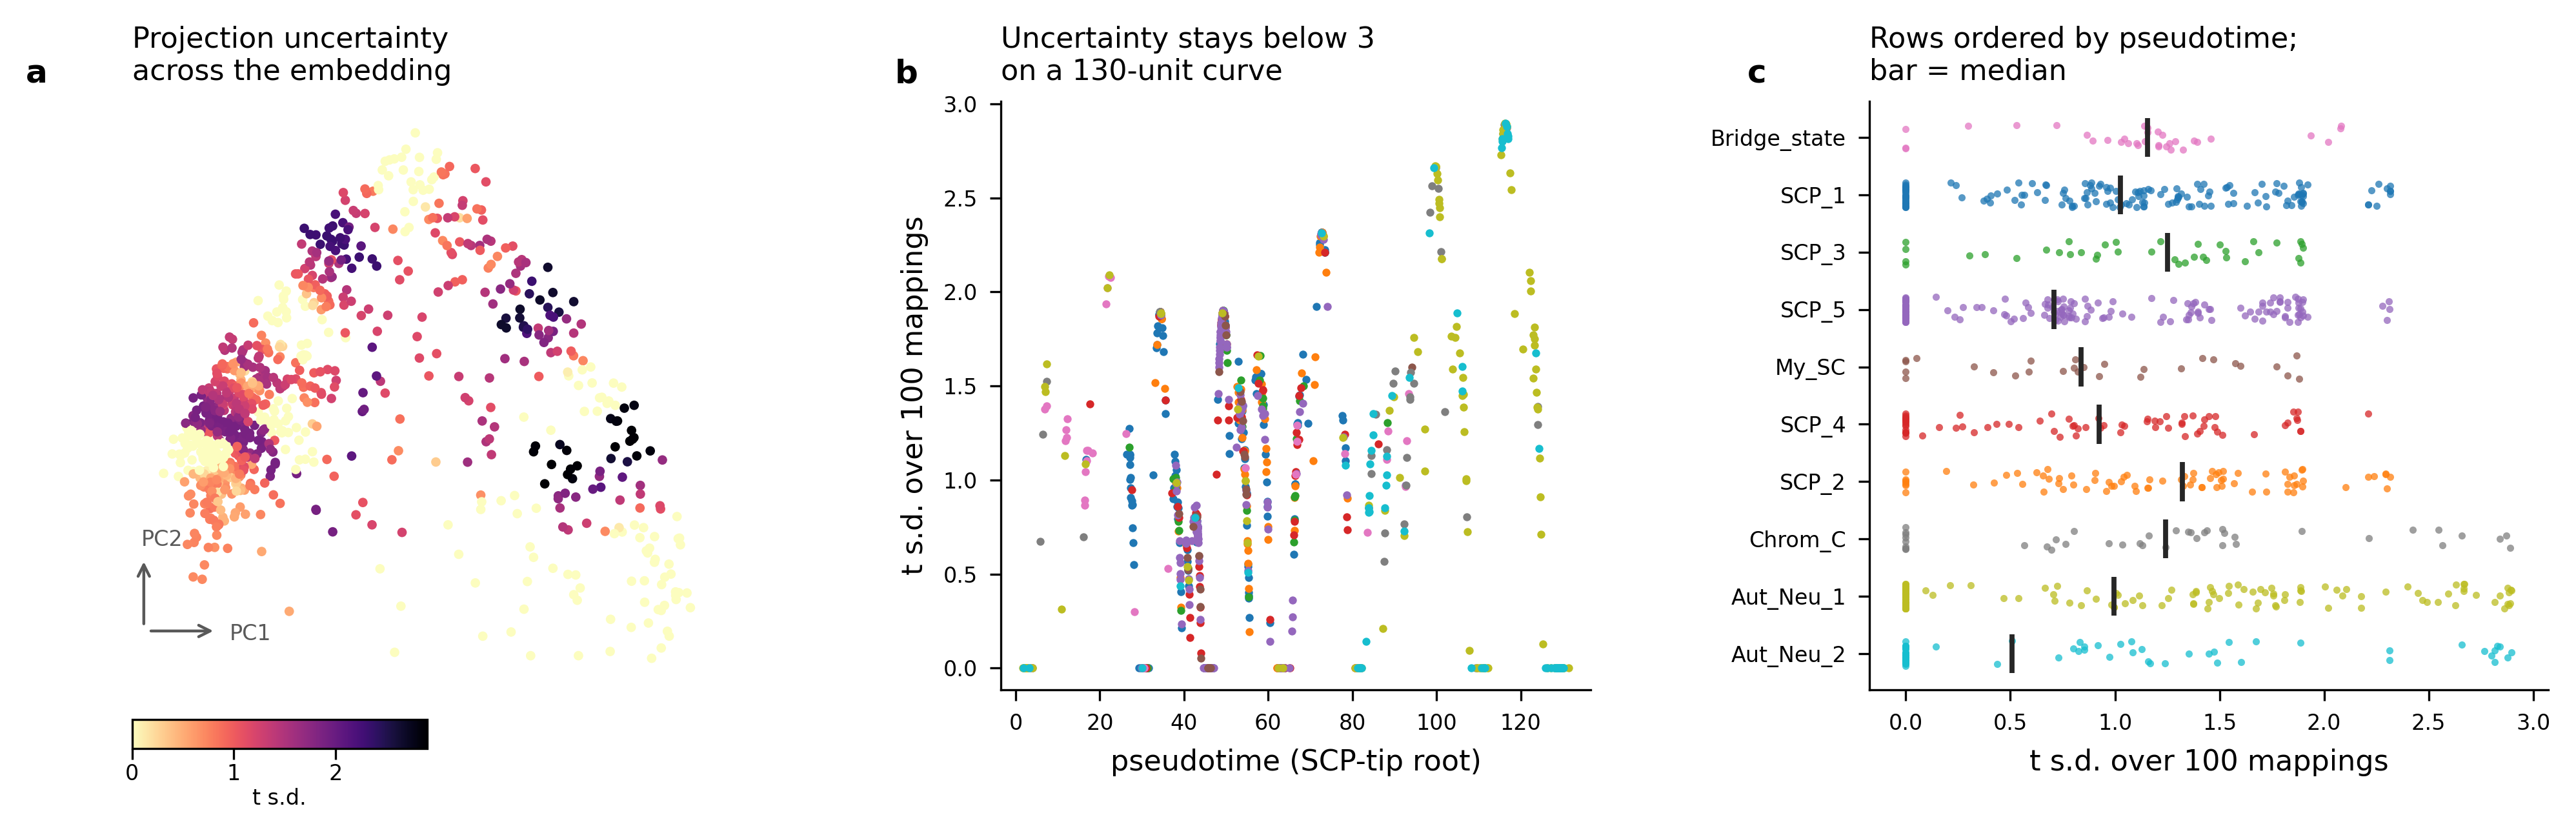

In [52]:
plt.close("all")
apply_figure_style(sizes=(8, 7, 6))

fig, axes = plt.subplots(1, 3, figsize=(12, 3),
                         gridspec_kw=dict(wspace=0.45, width_ratios=[1, 1, 1.15]))

ax = axes[0]
s = ax.scatter(pca[:, 0], pca[:, 1], s=7, c=tsd, cmap="magma_r", lw=0, rasterized=True)
ax.set_title("Projection uncertainty\nacross the embedding", fontsize=8, loc="left")
ax.set_xticks([]); ax.set_yticks([]); ax.margins(0.06)
for sp in ax.spines.values(): sp.set_visible(False)
cax = ax.inset_axes([0.0, -0.10, 0.5, 0.05])
cb = fig.colorbar(s, cax=cax, orientation="horizontal")
cb.set_label("t s.d.", fontsize=6, labelpad=1); cb.ax.tick_params(labelsize=6, pad=1)
ax.annotate("", xy=(0.15, 0.10), xytext=(0.02, 0.10), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=0.8, color="0.35"))
ax.annotate("", xy=(0.02, 0.23), xytext=(0.02, 0.10), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=0.8, color="0.35"))
ax.text(0.165, 0.095, "PC1", transform=ax.transAxes, fontsize=6, color="0.35", va="center")
ax.text(0.015, 0.245, "PC2", transform=ax.transAxes, fontsize=6, color="0.35")

ax = axes[1]
for t in order:
    m = (ct == t).values
    ax.scatter(tt[m], tsd[m], s=5, c=[pal[t]], lw=0, rasterized=True)
ax.set_xlabel("pseudotime (SCP-tip root)")
ax.set_ylabel("t s.d. over 100 mappings")
ax.set_title("Uncertainty stays below 3\non a 130-unit curve", fontsize=8, loc="left")
ax.margins(0.04); set_frame(ax)

ax = axes[2]
rs = np.random.default_rng(0)
for i, t in enumerate(summ.index):
    v = IN_tip.obs.loc[(ct == t).values, "t_sd"].values
    ax.scatter(v, i + rs.uniform(-0.22, 0.22, v.size), s=4, c=[pal[t]], lw=0, alpha=0.75)
    ax.plot([np.median(v)] * 2, [i - 0.34, i + 0.34], color="0.15", lw=1.4, solid_capstyle="butt")
ax.set_yticks(range(len(summ.index))); ax.set_yticklabels(summ.index, fontsize=6)
ax.invert_yaxis(); ax.set_xlabel("t s.d. over 100 mappings")
ax.set_title("Rows ordered by pseudotime;\nbar = median", fontsize=8, loc="left")
ax.margins(x=0.06, y=0.03); set_frame(ax)

for a, L in zip(axes, "abc"): panel_letter(a, L)
fig.savefig(root_figure / "pseudotime_uncertainty.png", dpi=300, bbox_inches="tight")
r = fig.canvas.get_renderer()
texts = [(t, t.get_window_extent(r)) for t in fig.findobj(mpl.text.Text) if t.get_text().strip() and t.get_visible()]
print("overlaps:", [(a.get_text()[:20], b.get_text()[:20]) for i,(a,ba) in enumerate(texts)
                    for b,bb in texts[i+1:] if ba.overlaps(bb)])
print("max t_sd:", round(float(tsd.max()), 2), "| curve length:", round(rng, 1))

### Projection uncertainty is negligible

median t_sd = 0.95 on a 129.8-unit curve — 0.7% of the range — with a 95th percentile of 2.32 and a maximum of 2.90. Not one of the 870 cells exceeds 5% of curve length. Per-type medians run from 0.51 (Aut_Neu_2) to 1.32 (SCP_2), so no cell type is systematically ill-placed. The values are identical under both roots, as expected — rooting shifts the origin, it doesn't change how consistently cells map to the graph.

#### The useful conclusion is a negative one

n_map=100 isn't buying much here. The ordering is tightly determined given the curve. What's actually uncertain is the curve itself — whether one line is the right topology — and no amount of mapping replication addresses that. n_map=1 would have given you the same picture in a fraction of the time, which is worth knowing before you run this on the larger compartments.

#### `Panel a` does show some spatial structure 

The higher values sit in the dense SCP region and at the neuronal end, where cells are equidistant from several nodes — but at a scale of ~2 units on a 130-unit axis it has no interpretive consequence.

- innervation_tsd_by_celltype.csv — per-type n, mean pseudotime under both roots, median t_sd, and t_sd as a percentage of curve length

- cardiomyocytes02.rds, endothelial.rds and fibroblasts.rds are downloaded and ready for step 6, but I need your call on the question from the last turn before fitting them, since it determines how each compartment gets rooted: keep the published curve + marker-root recipe, switch to tip-rooting, or refit as branching trees. The compartments are larger and genuinely branched (fibroblast heterogeneity is a stated focus of the paper), so the topology choice matters more there than it did here.

### Envirnoment vars needed: R_HOME, LD_LIBRARY_PATH

In [53]:
import time, warnings, contextlib, io
warnings.simplefilter("ignore")

# R
# install.packages('mgcv')
# Rscript -e 'library(mgcv); sessionInfo()'

# python -m rpy2.situation

import rpy2.robjects as ro 

In [54]:
!python -m rpy2.situation

/home/flavio/miniforge3/envs/renv/bin/python: Error while finding module specification for 'rpy2.situation' (ModuleNotFoundError: No module named 'rpy2')


In [55]:
print("rpy2 ok | R:", ro.r("R.version.string")[0], "| mgcv:", ro.r('as.character(packageVersion("mgcv"))')[0])

rpy2 ok | R: R version 4.5.3 (2026-03-11) | mgcv: 1.9.4


### Plotting trends (trends_<cell>.png)

What it needs is a fitted object, and the one you have doesn't qualify: 

- data/h5ad/innervation_selection_scfates.h5ad has layers: ['counts'] only, no fitted, and no signi/A in var.

That last line matters: scf.tl.fit subsets the object to the significant genes in place, and I lost a fitted object once already by not saving it — the figure then can't be rebuilt without redoing the GAMs.

trends_figure(adata, title, out_png, k=6, n_bins=60) returns (fig, modules) where modules is a Series of module label per gene. It clusters z-scored fitted profiles and bins per segment, so it works on trees as well as curves.

In [56]:
IN = sc.read_h5ad(root_h5 / "vfd40245c_innervation_selection_scfates.h5ad")
for c in ("seg", "milestones", "edge", "cell.types"):
    IN.obs[c] = IN.obs[c].astype(str).astype("category")

# reroot at the SCP tip (the saved graph is PENK-rooted)
R = np.asarray(IN.obsm["X_R"]); labs = IN.obs["cell.types"].astype(str).values
frac = {int(tp): float(np.mean([l.startswith("SCP") for l in labs[np.argsort(R[:, tp])[::-1][:30]]]))
        for tp in map(int, IN.uns["graph"]["tips"])}
del IN.uns["graph"]["root"]

scf.tl.root(IN, max(frac, key=frac.get))
scf.tl.pseudotime(IN, n_jobs=1, n_map=100, seed=42)

scf.tl.test_association(IN, n_jobs=15, fdr_cut=1e-4, A_cut=0.3)   # ~16 s
scf.tl.fit(IN, n_jobs=15)

node 0 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:17<00:00,  5.70it/s]
    finished (0:00:17) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.
test features for association with the trajectory
    single mapping : 100%|██████████| 5000/5000 [00:20<00:00, 242.65it/s]
    found 1725 significant features (0:00:20) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var[

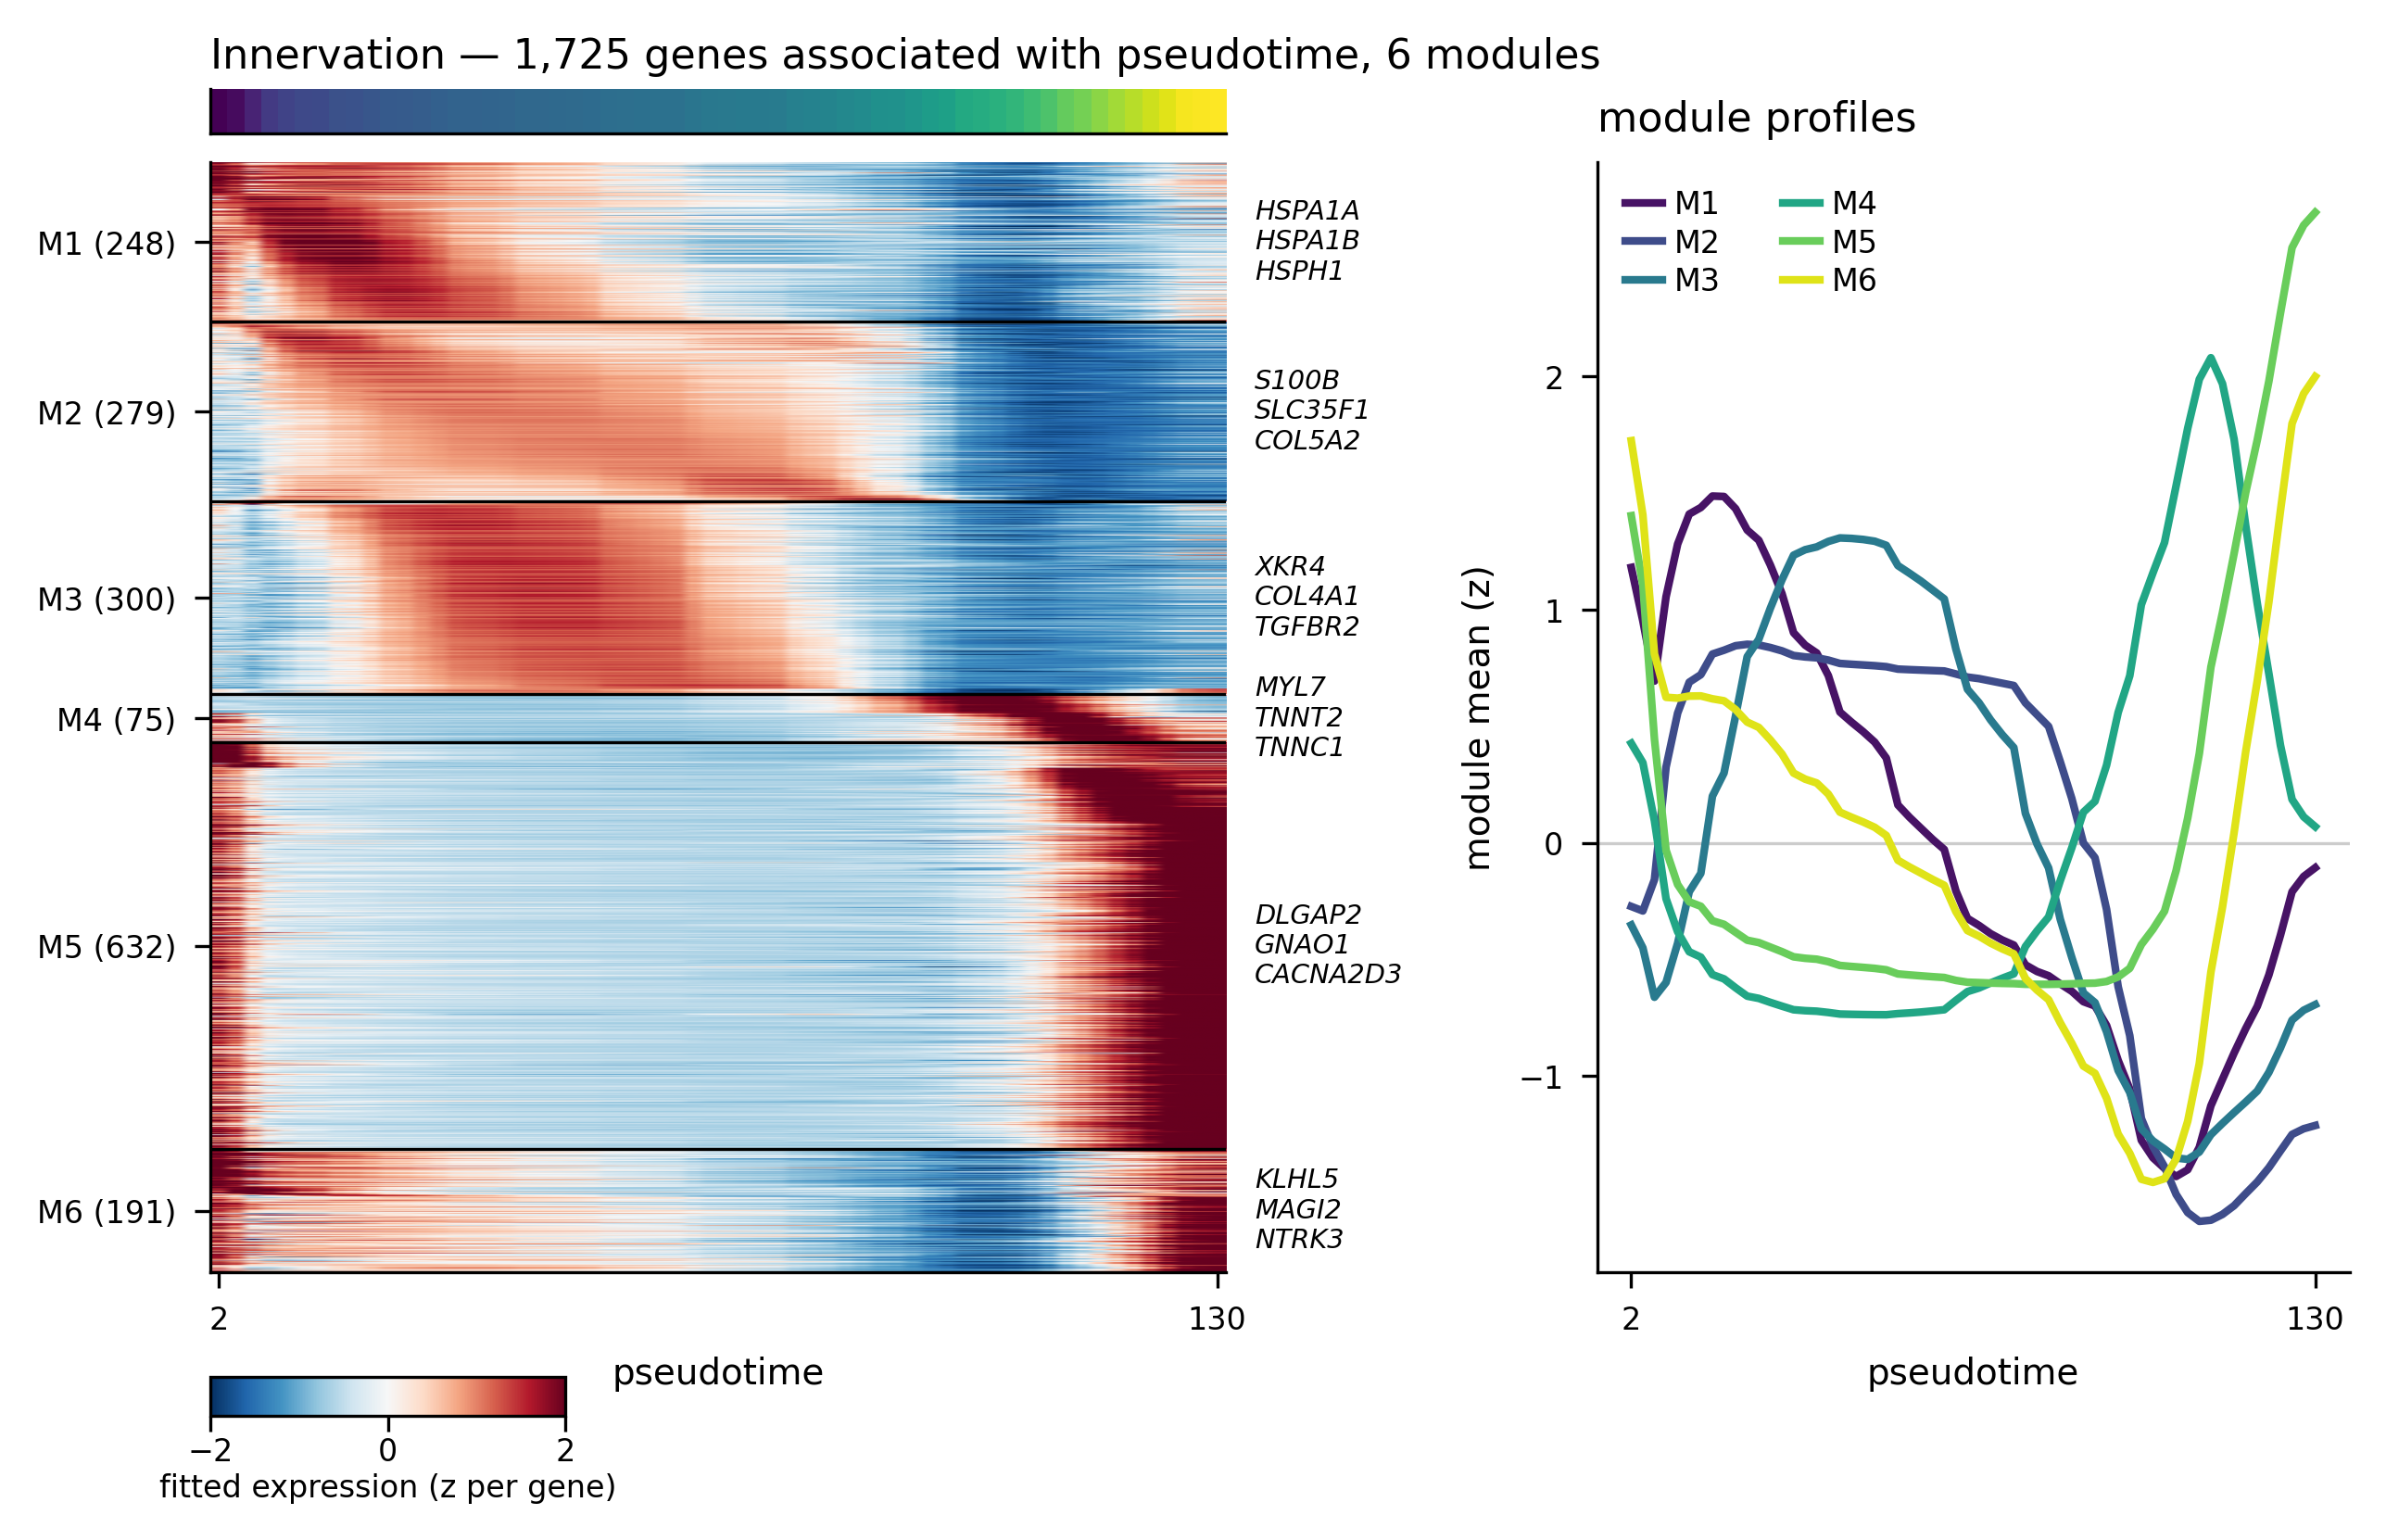

In [57]:

from libs.trends_figure import trends_figure
fig, mod = trends_figure(IN, "Innervation", root_figure / "trends_innervation.png", k=6)

### It is Ok

1,725 genes, module sizes 248/279/300/75/632/191, same representative genes per module. 

Yours is smoother because the tip-rooted fit has one segment, so pooled and per-segment binning coincide.

### M4 is the one to look at critically

M4: MYL7, TNNT2, TNNC1 are cardiomyocyte sarcomere genes, in a neural crest compartment. Finding where they come from:

In [58]:
TABLES

PosixPath('/home/flavio/uv/neural_crest/results/tables')

In [59]:
'''
mods = pd.read_csv(host.artifact_path("03461c2e-4257-4b96-99b6-2d6c7a1a5a9c"), index_col=0)
ad = sc.read_h5ad(host.artifact_path("fd40245c-489b-4179-a5a2-f53c68a49e1e")) if False else \
     sc.read_h5ad(host.artifact_path(IDS["innervation_selection_scfates.h5ad"]))
'''

mods = pd.read_csv(TABLES / "innervation_gene_modules.csv", index_col=0)
filename = root_h5 / "innervation_selection_scfates.h5ad"
ad = sc.read_h5ad(filename)

m4 = [g for g in mods.index[mods["module"] == 4] if g in ad.raw.var_names]
X = np.asarray(ad.raw[:, m4].X.todense())
score = pd.Series(X.mean(1), index=ad.obs_names)

by_type = pd.DataFrame({
    "n": ad.obs["cell.types"].value_counts(),
    "M4_mean": score.groupby(ad.obs["cell.types"].values, observed=True).mean(),
    "pct_cells_top_decile": 100 * (score > score.quantile(0.9)).groupby(
        ad.obs["cell.types"].values, observed=True).mean(),
}).sort_values("M4_mean", ascending=False).round(3)

print(f"M4 = {len(m4)} genes; top: {', '.join(mods.index[mods['module']==4][:6])}\n")

top_samples = (score.groupby(ad.obs["sampleID"].values).mean()
                 .sort_values(ascending=False).head(4).round(3))

print("\nhighest M4 by sample:", top_samples.to_dict())
print("cells above the 90th pct of M4:", int((score > score.quantile(0.9)).sum()),
      "| their median nCount:", float(ad.obs.loc[score > score.quantile(0.9), "nCount_RNA"].median()),
      "vs overall:", float(ad.obs["nCount_RNA"].median()))

by_type

M4 = 75 genes; top: METTL7A, TLX2, CKM, TNNC1, PLN, CSRP3


highest M4 by sample: {'TenX158_2': 0.3659999966621399, 'TenX158_1': 0.3230000138282776, 'TenX127_1': 0.3070000112056732, 'TenX151_3': 0.257999986410141}
cells above the 90th pct of M4: 87 | their median nCount: 2281.0 vs overall: 12384.5


,n,M4_mean,pct_cells_top_decile
Chrom_C,41,0.390,60.976
Aut_Neu_1,145,0.231,24.828
Aut_Neu_2,69,0.198,13.043
Bridge_state,34,0.150,5.882
SCP_4,72,0.108,4.167
SCP_1,168,0.106,1.190
SCP_2,80,0.095,2.500
SCP_5,195,0.088,3.077
My_SC,28,0.082,3.571
SCP_3,38,0.081,2.632


### Trajectory

In [60]:
warnings.simplefilter("ignore")

for c in ("seg", "milestones", "edge", "cell.types"):
    ad.obs[c] = ad.obs[c].astype(str).astype("category")

ad.obs["t"] = ad.obs["t_SCPtip_root"]          # the monotone axis for display

In [61]:
# del(plot_pseudotime_fates)

import importlib, libs.plot_fates as pf
importlib.reload(pf)
from libs.plot_fates import plot_pseudotime_fates, terminal_fates   # rebind the names


| element	| value in (8, 7, 6)	| what it sets |
|-----------|-----------|-----------|
| base	| 8 pt | font.size, axes.labelsize, axes.titlesize — panel titles, axis labels, series/direct labels |
| secondary	| 7 pt	| legend.fontsize — legends and annotations |
| tick	| 6 pt	| xtick.labelsize, ytick.labelsize |

In [62]:
apply_figure_style(sizes=(10, 9, 8))    # poster or slide
apply_figure_style(sizes=(7, 6, 5))     # dense multi-panel supplement


overlaps: []
preprocessed: 870 cells x 5000 HVGs
inferring a principal curve --> parameters used 
    30 principal points, mu = 0.1, lambda = 0.01
    finished (0:00:00) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.
automatic root selection using PENK values
node 12 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:02<00:00, 43.14it/s]
    finished (0:00:02) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .ob

,seg,n,terminal,dominant,length
0,1,714,True,SCP_5,96.936
1,2,156,True,Aut_Neu_1,34.546


<Figure size 2400x1600 with 0 Axes>

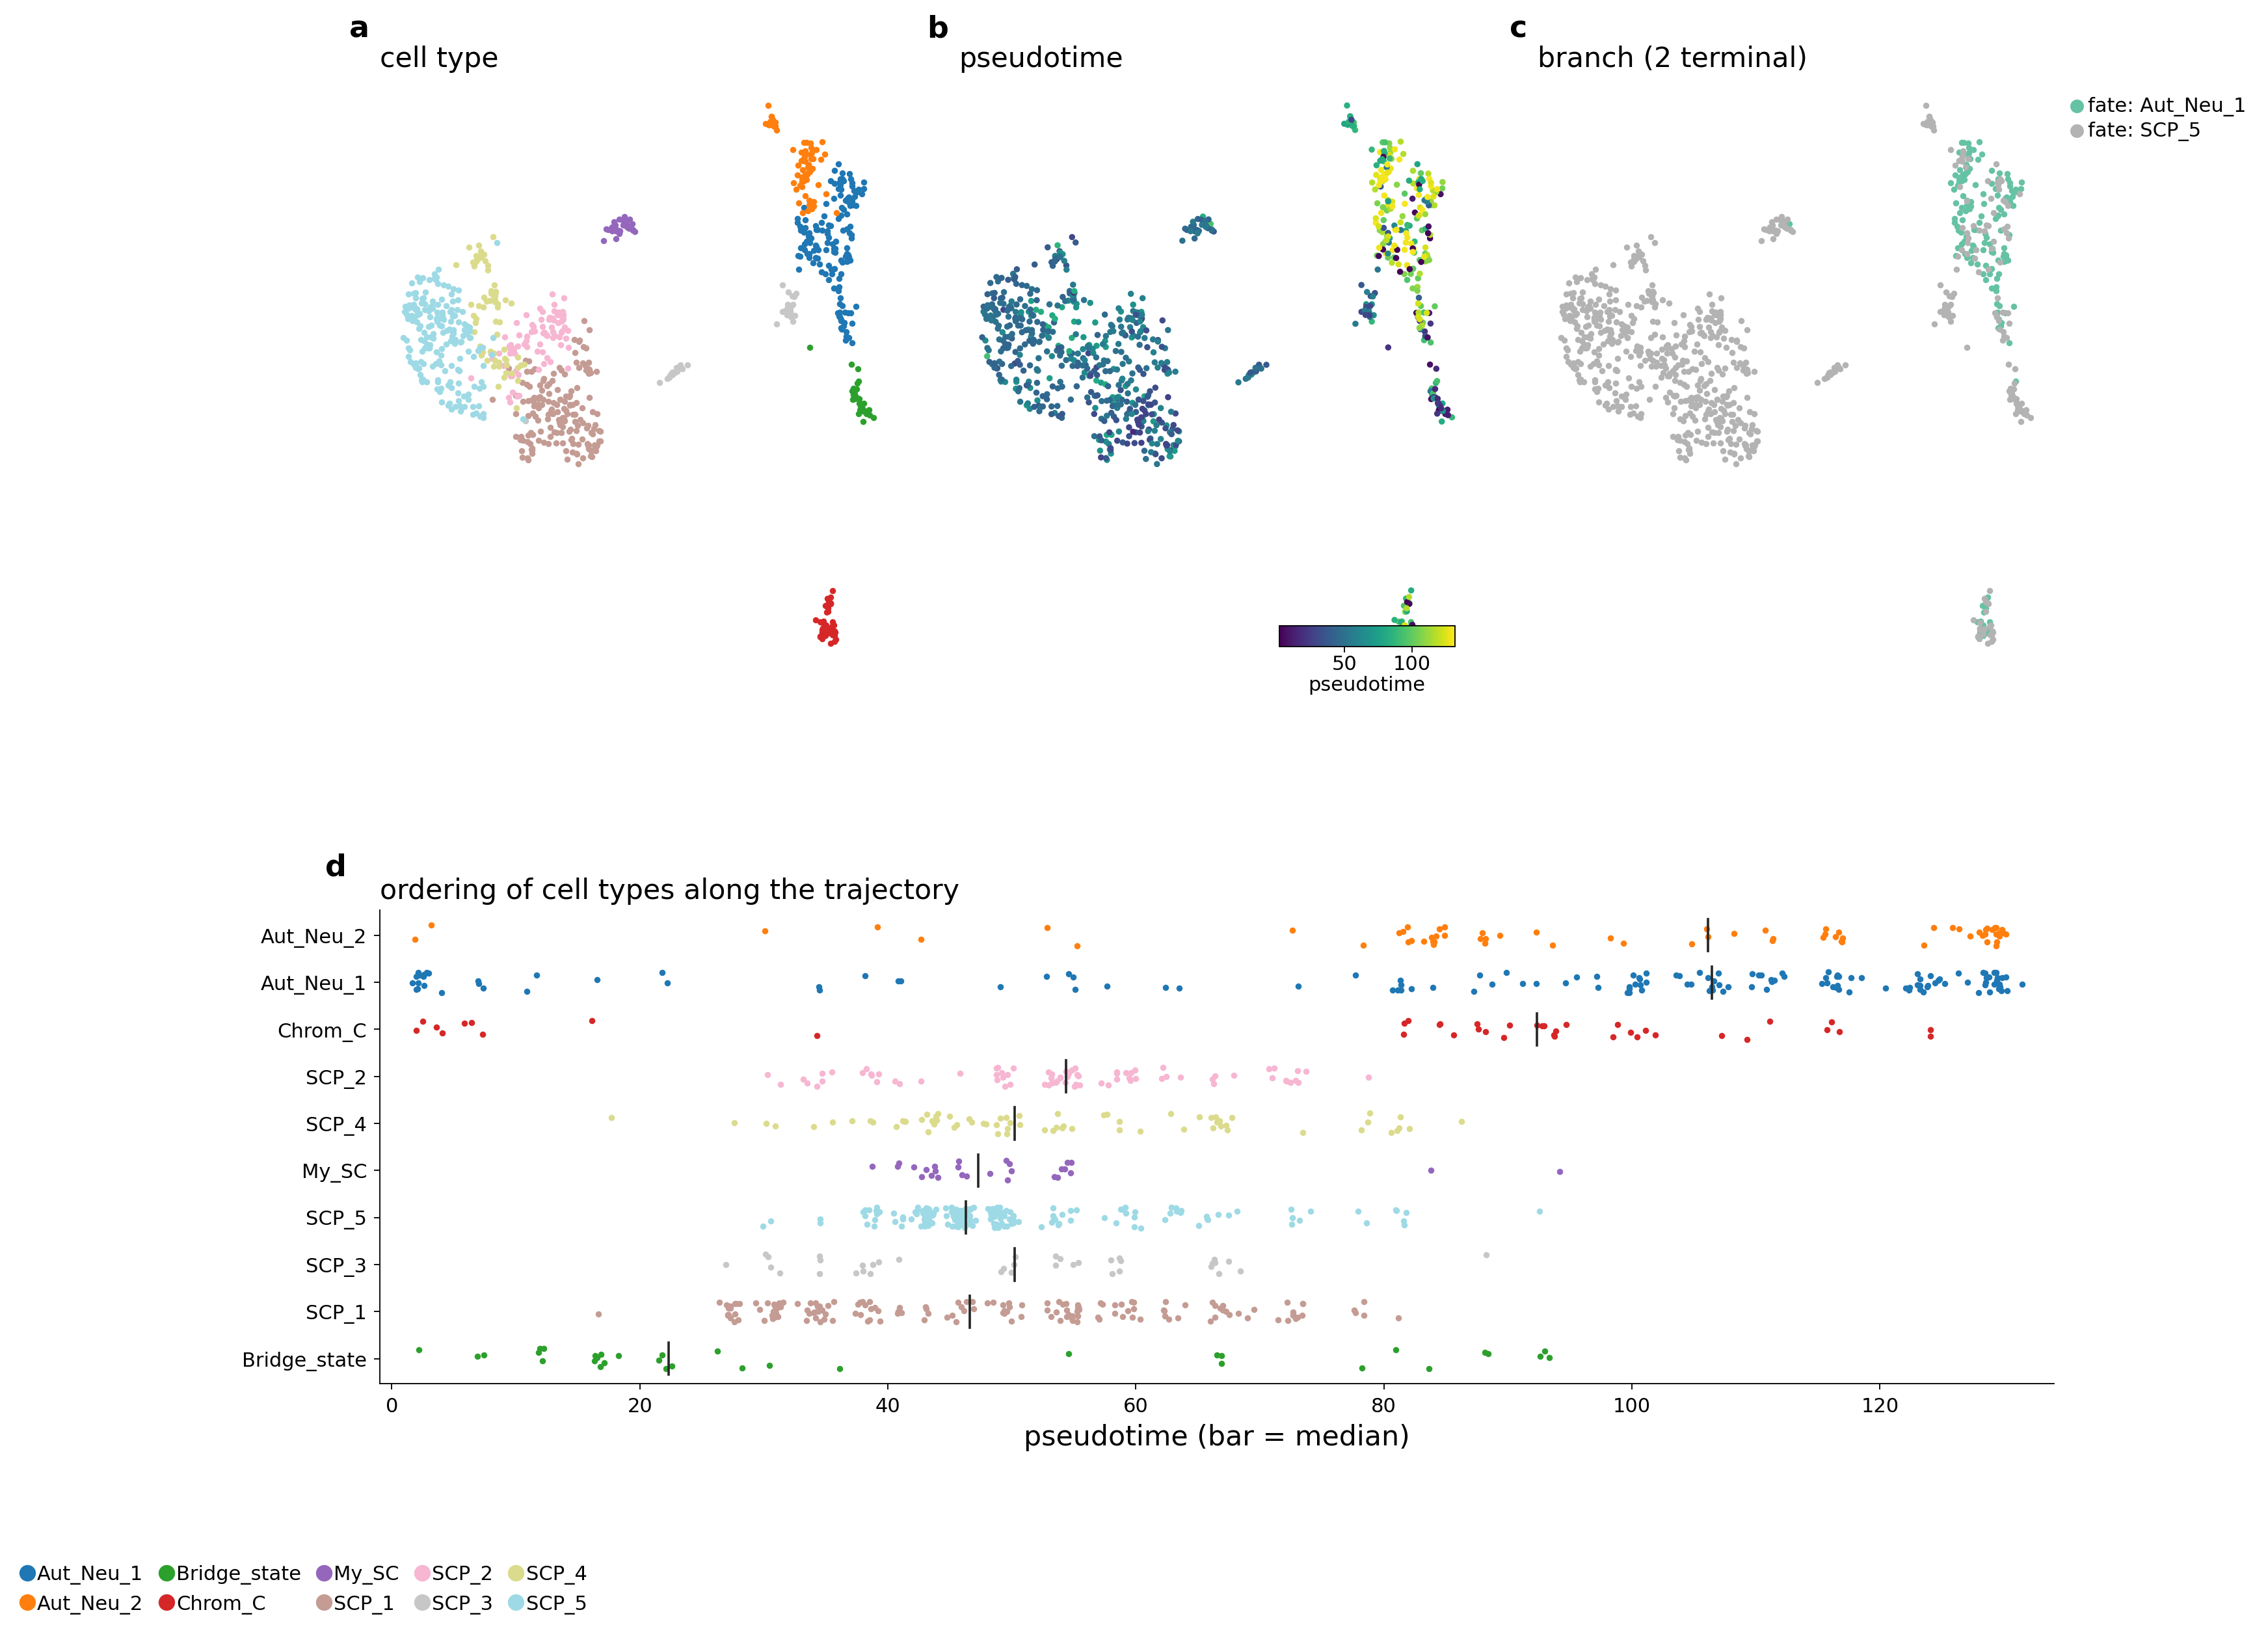

In [63]:
plt.figure(figsize=(12, 8))
fig, seg_info = plot_pseudotime_fates(ad, "pseudotime_fates.png", label_key="cell.types",
                                      basis="X_umap_subset", title=None, figsize=(15, 12), sizes=(14, 14, 10))
r = fig.canvas.get_renderer()
tx = [(x, x.get_window_extent(r)) for x in fig.findobj(mpl.text.Text) if x.get_text().strip() and x.get_visible()]
print("overlaps:", [(a.get_text()[:16], b.get_text()[:16]) for i,(a,ba) in enumerate(tx) for b,bb in tx[i+1:] if ba.overlaps(bb)])
IN = preprocess(sel, n_top_genes=5000, n_neighbors=25, layer="counts")         # 870 x 5000
fit_curve(IN, root_gene="PENK", nodes=30, n_map=100, n_jobs=15, seed=42)  
seg_info

### Plot markers and uncertainties

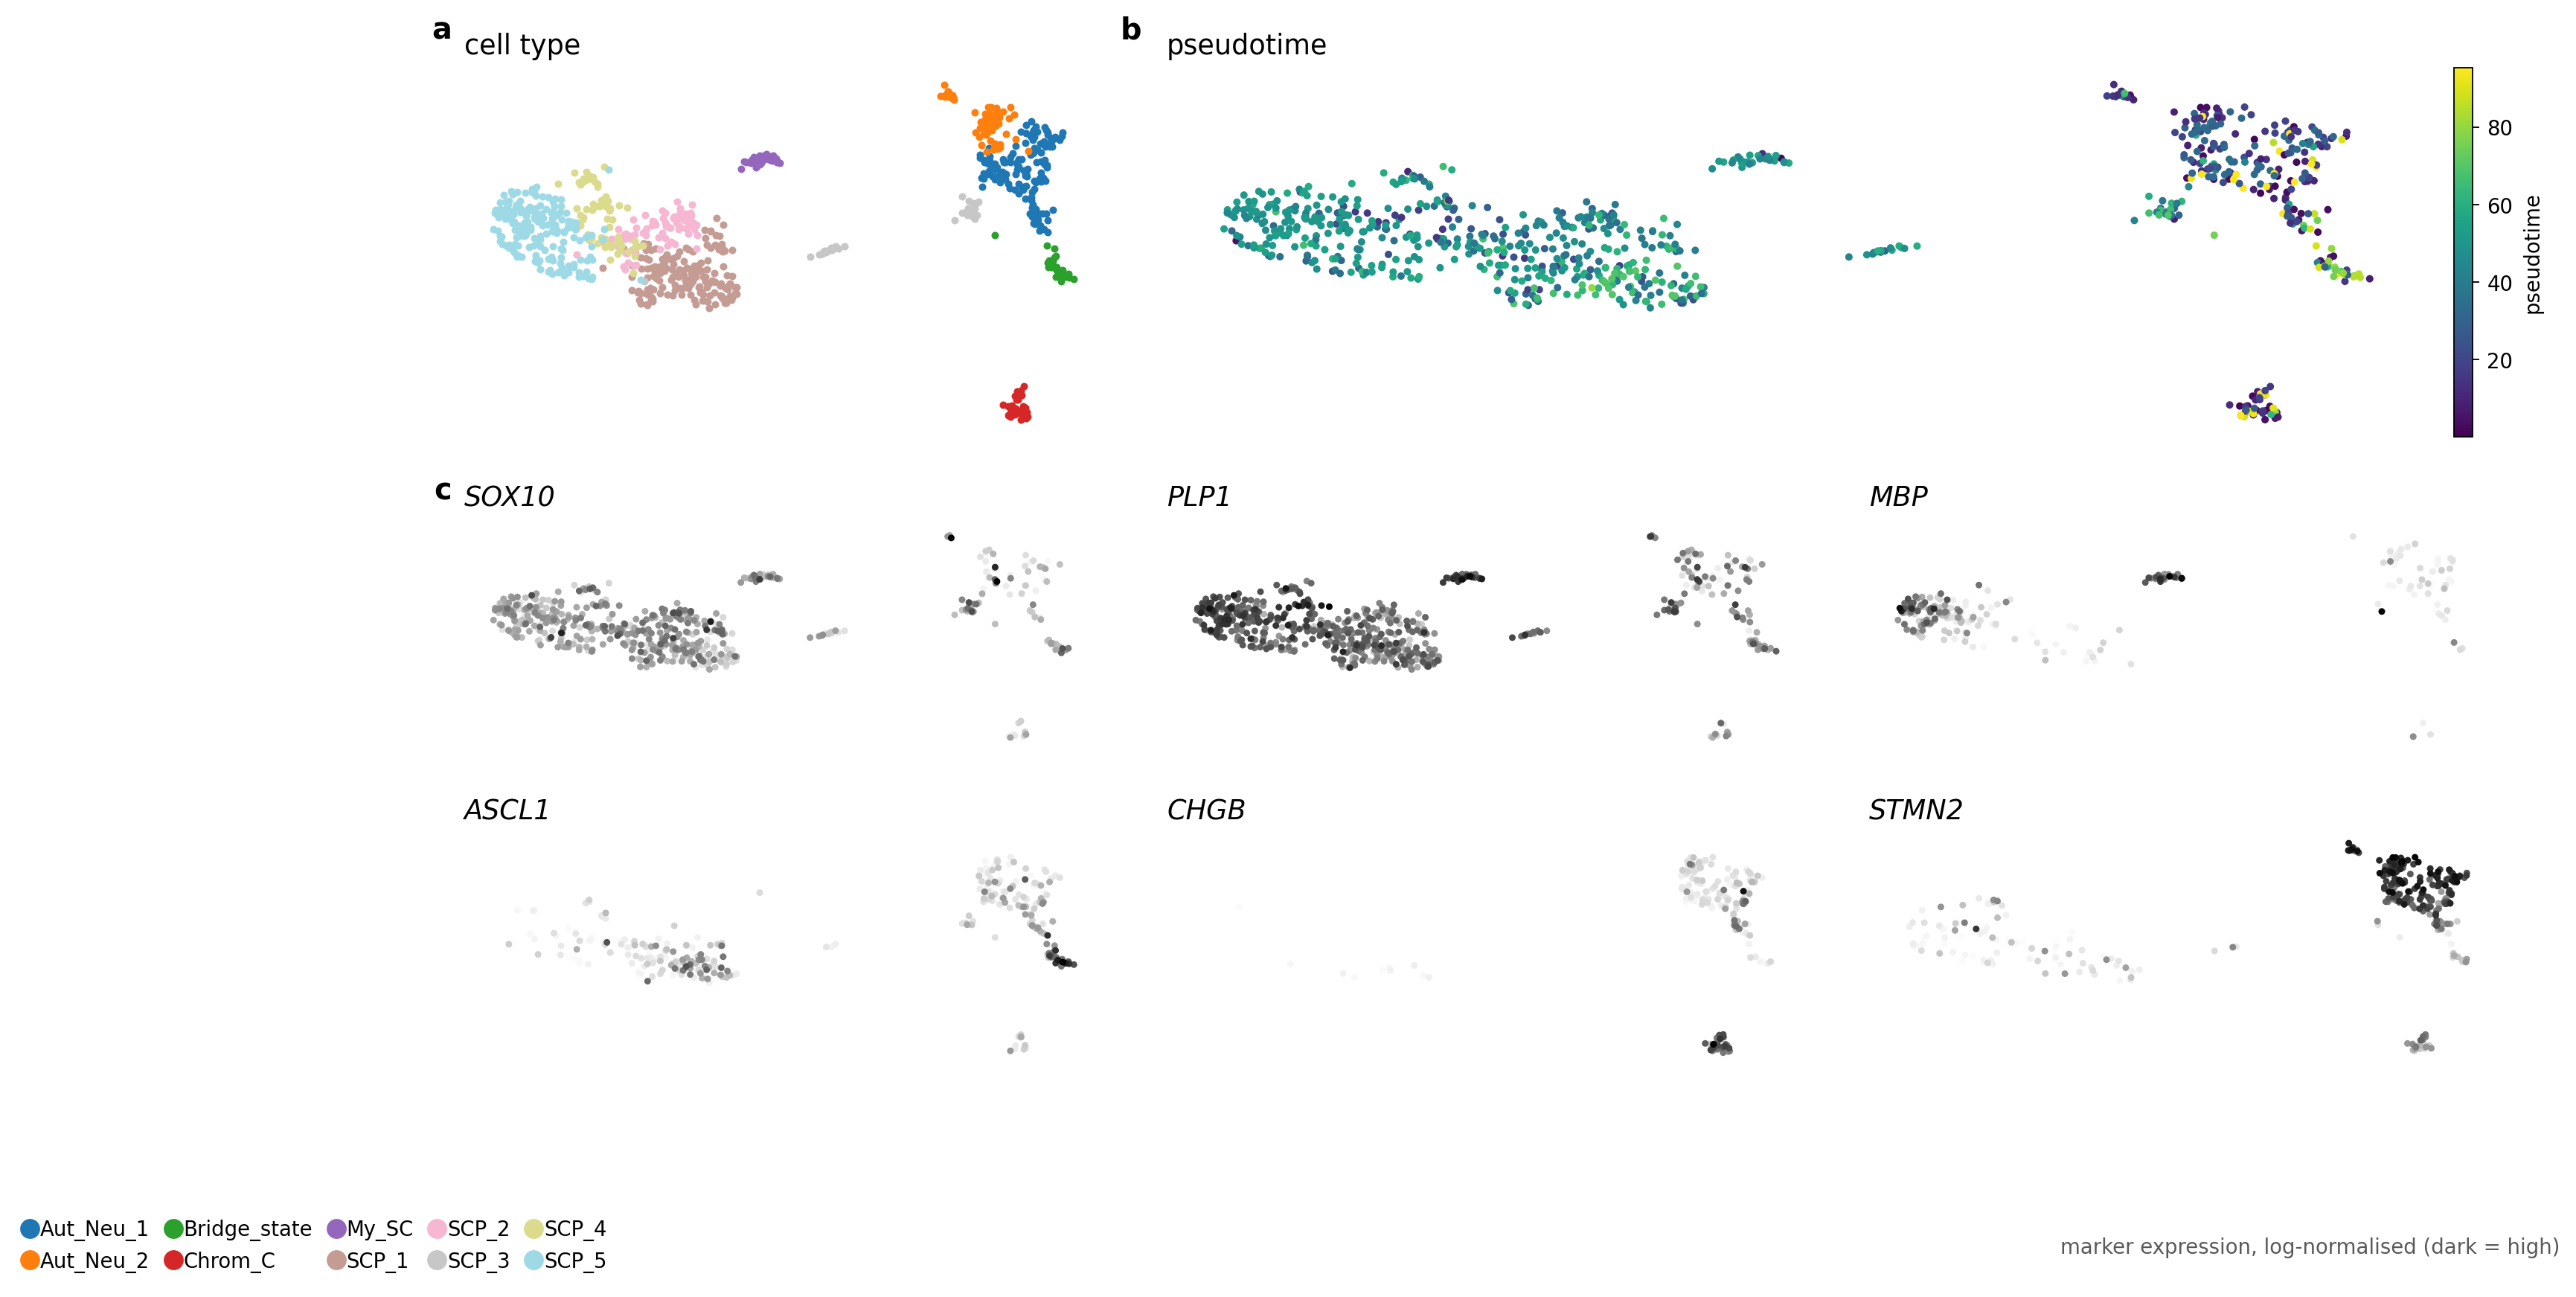

In [64]:
import importlib, libs.plot_fates as pf
importlib.reload(pf)

fig = pf.plot_markers(IN, ["SOX10", "PLP1", "MBP", "ASCL1", "CHGB", "STMN2"],
                root_figure / "innervation_markers.png", figsize=(16,8), sizes=(12, 12, 9))

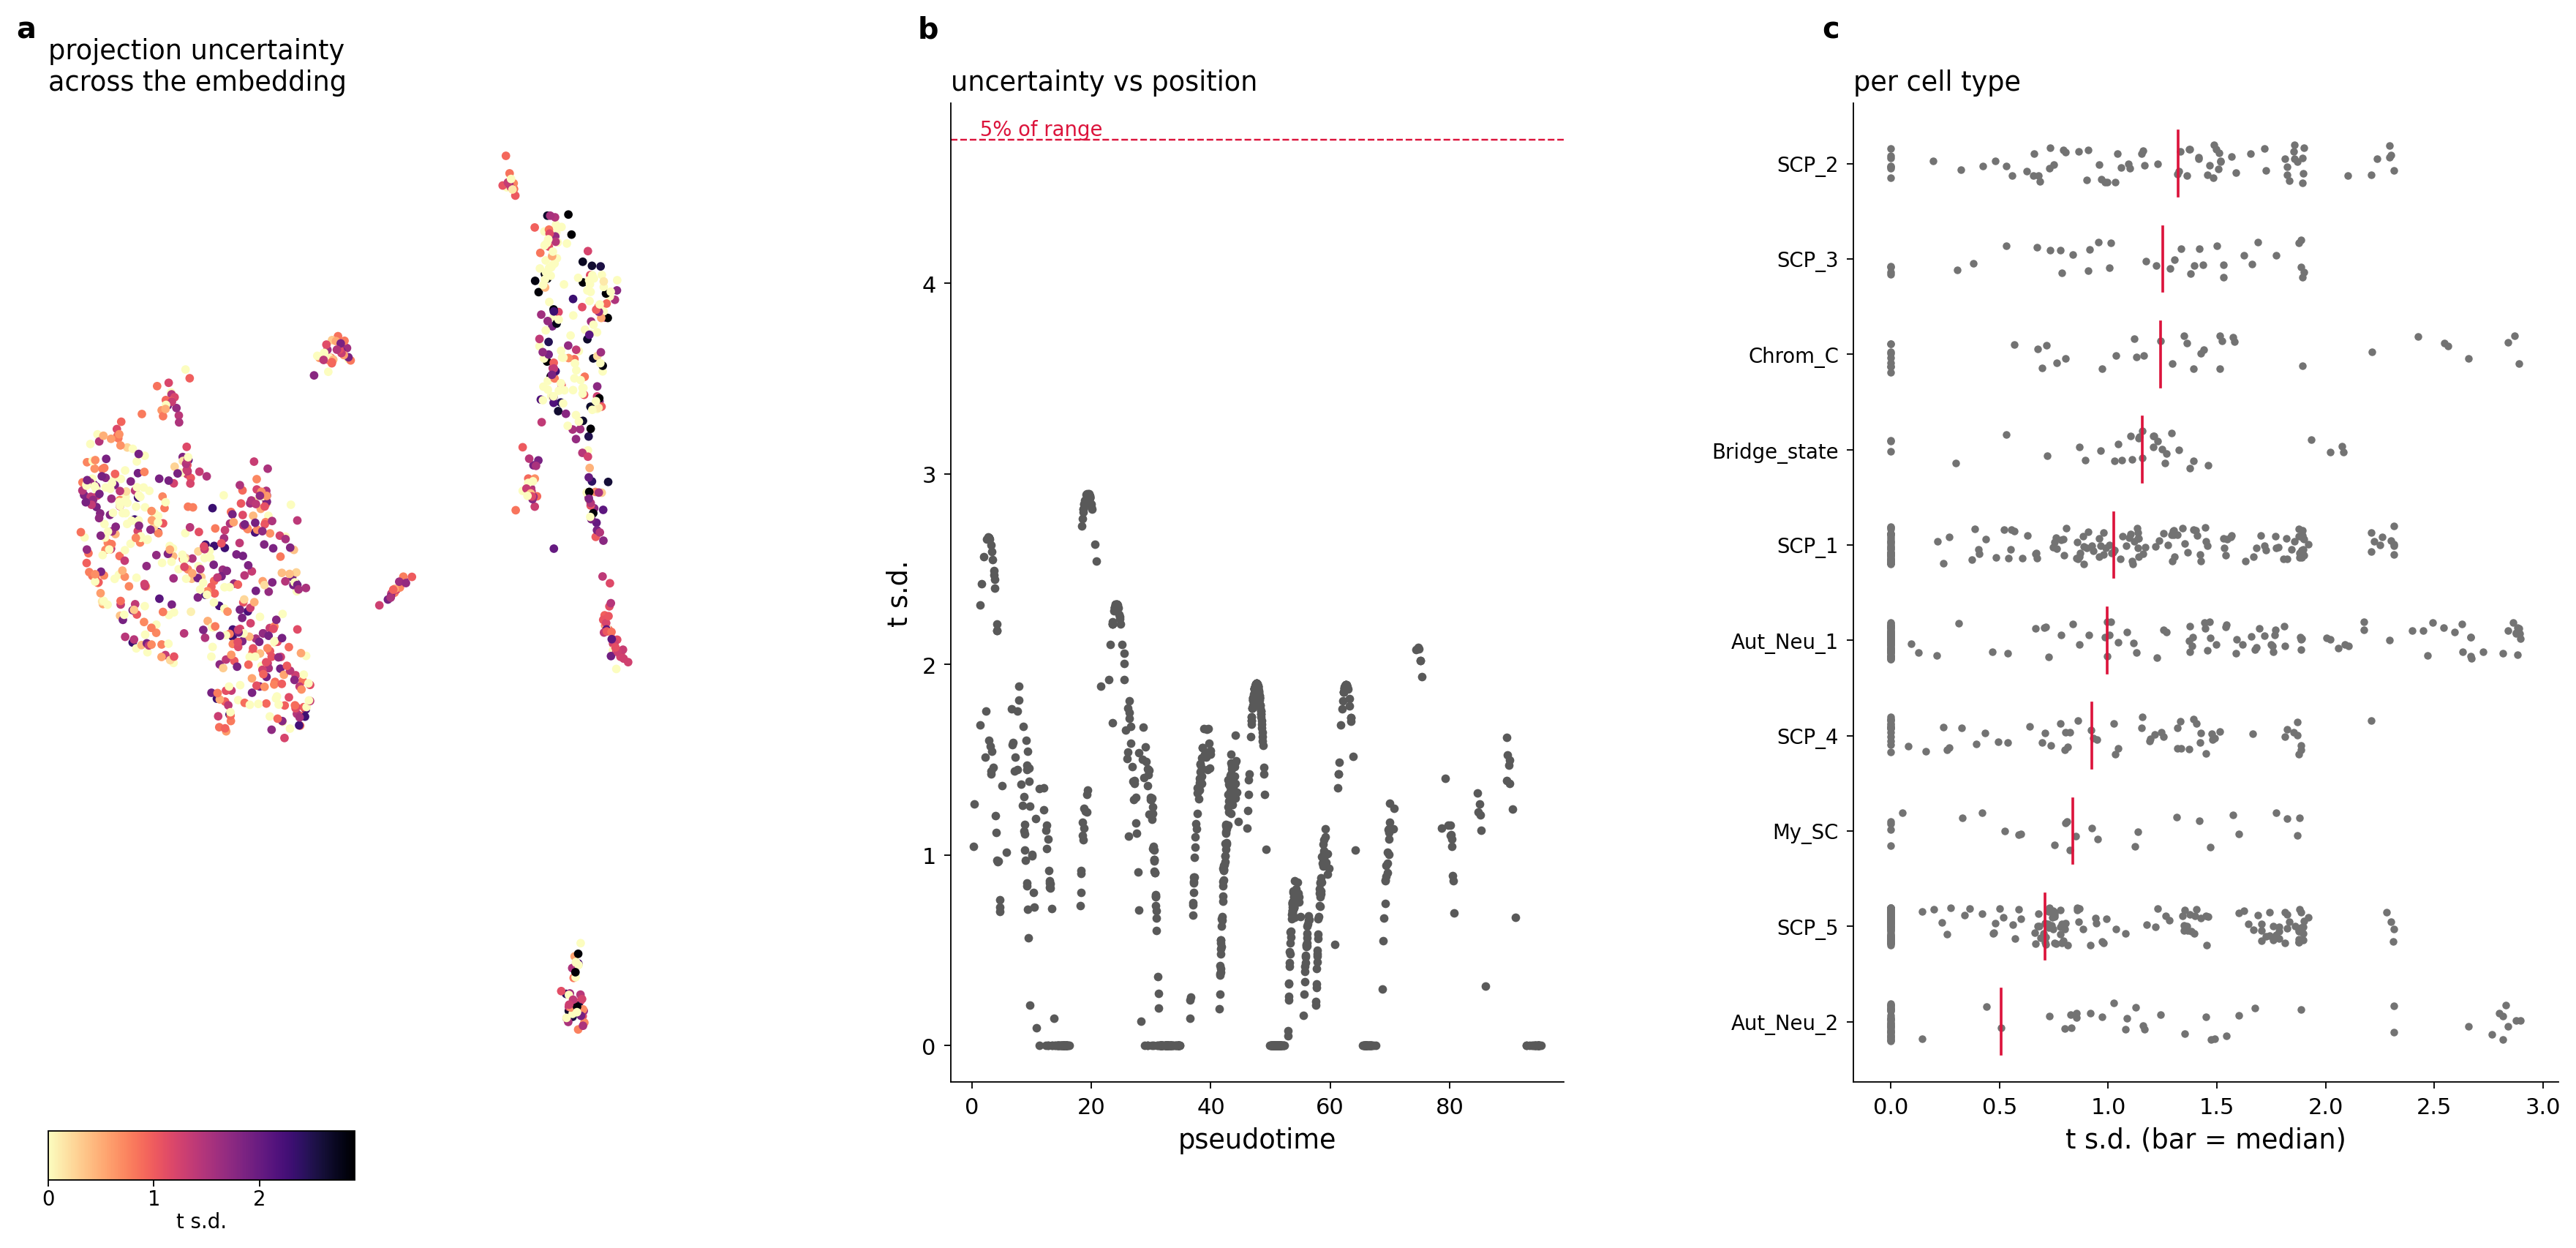

In [65]:
fig = pf.plot_uncertainty(IN, root_figure / "pseudotime_uncertainty.png", figsize=(20, 8), sizes=(12, 12, 9))

### For the other compartments

Those aren't in your project — data/h5ad/ has only the innervation objects, and data/bundles/ only IN_sel. 

Each compartment needs the full chain from its RDS:

```R
Rscript src/libs/convert_seurat_to_h5ad.R data/cardiomyocytes02.rds data/bundles/cardiomyocytes02

```

```bash
cd /home/flavio/uv/neural_crest
ls -la download_dataset/data/*.rds | awk '{printf "%6.0f MB  %s\n", $5/1048576, $9}'
for f in cardiomyocytes02 endothelial fibroblasts; do
  echo "=== $f"
  /usr/bin/time -f "  %e s, %M KB peak" Rscript src/libs/convert_seurat_to_h5ad.R download_dataset/data/$f.rds data/bundles/$f 2>&1 | grep -vE "^$"
done
echo "=== bundles now:"; du -sh data/bundles/* 2>/dev/null
```

In [66]:
root_bundles

PosixPath('/home/flavio/uv/neural_crest/data/bundles')

In [67]:
os.listdir(root_bundles)

['endothelial', 'fibroblasts', 'cardiomyocytes02', 'IN_sel']

In [73]:
import pickle

def get_name(name):
    return root_h5 / f"{name}_fitted.h5ad"

def save_fitted(a, name):
    epg = a.uns.pop("epg", None)                # ragged Edges list — not h5ad-safe

    filename = get_name(name)

    try:
        ret = True
        a.write_h5ad(filename)
        if epg is not None:
            with open(root_h5 / f"{name}_epg.pkl", "wb") as f:
                pickle.dump(epg, f)
            a.uns["epg"] = epg                       # keep it live in this session
    except Exception as e:
        print(f"Error occurred while saving fitted data for {filename}: {e}")
        ret = False

    return ret

def load_fitted(name):
    filename = get_name(name)
    if not filename.exists():
        return None
    
    a = sc.read_h5ad(filename)
    pk = root_h5 / f"{name}_epg.pkl"
    if pk.exists():
        with open(pk, "rb") as f:
            a.uns["epg"] = pickle.load(f)        # restores scf.pl.graph
    return a

In [80]:
from libs.assemble_h5ad import assemble
# from libs.plot_fates import terminal_fates
# from libs.trends_figure import trends_figure
import libs.run_scfates as rs

import importlib, libs.trends_figure as tf
importlib.reload(tf)

n_jobs = 12

'''
name = "cardiomyocytes02"
a = load_fitted(name)

if a is None:
    a = assemble(root_bundles / "cardiomyocytes02")

    a = a[~a.obs["cell.types"].astype(str).str.contains("_excl_")].copy()
    a.obs["cell.types"] = a.obs["cell.types"].astype(str).astype("category")

    # 06_3 preprocessing, then a tree on the harmony embedding
    rs.preprocess(a, n_top_genes=5000, n_neighbors=25, layer="counts", copy=False)

    scf.tl.tree(a, Nodes=20, use_rep="X_harmony_subset", ndims_rep=10,
                method="ppt", ppt_sigma=0.1, ppt_lambda=100, seed=42)
    # root at the progenitor-rich tip, or an internal node for fibroblasts
    scf.tl.root(a, progenitor_tip(a, ("Prol_CM", "Immat_CM"))[0])
    scf.tl.pseudotime(a, n_jobs=n_jobs, n_map=100, seed=42)
    scf.tl.test_association(a, n_jobs=n_jobs, fdr_cut=1e-4, A_cut=0.3)
    scf.tl.fit(a, n_jobs=n_jobs)

    save_fitted(a, name)

fig = tf.trends_figure(a, "Cardiomyocytes", root_figure / "trends_cardiomyocytes02.png", k=6, figsize=(17, 7))
'''

'\nname = "cardiomyocytes02"\na = load_fitted(name)\n\nif a is None:\n    a = assemble(root_bundles / "cardiomyocytes02")\n\n    a = a[~a.obs["cell.types"].astype(str).str.contains("_excl_")].copy()\n    a.obs["cell.types"] = a.obs["cell.types"].astype(str).astype("category")\n\n    # 06_3 preprocessing, then a tree on the harmony embedding\n    rs.preprocess(a, n_top_genes=5000, n_neighbors=25, layer="counts", copy=False)\n\n    scf.tl.tree(a, Nodes=20, use_rep="X_harmony_subset", ndims_rep=10,\n                method="ppt", ppt_sigma=0.1, ppt_lambda=100, seed=42)\n    # root at the progenitor-rich tip, or an internal node for fibroblasts\n    scf.tl.root(a, progenitor_tip(a, ("Prol_CM", "Immat_CM"))[0])\n    scf.tl.pseudotime(a, n_jobs=n_jobs, n_map=100, seed=42)\n    scf.tl.test_association(a, n_jobs=n_jobs, fdr_cut=1e-4, A_cut=0.3)\n    scf.tl.fit(a, n_jobs=n_jobs)\n\n    save_fitted(a, name)\n\nfig = tf.trends_figure(a, "Cardiomyocytes", root_figure / "trends_cardiomyocytes02.png"

In [72]:
a2 = load_fitted(name)
a2

AnnData object with n_obs × n_vars = 20366 × 378
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampleID', 'DoubletFlag', 'DoubletScore', 'DropletClass', 'age', 'age_round_up', 'age_round_down', 'percent_ribo', 'percent_mito', 'percent_hb', 'percent_hsp', 'apoptotic_maybe', 'S.Score', 'G2M.Score', 'Phase', 'clusters_louvain_unfilt', 'clusters_louvain_dataset', 'pANN', 'DF.classifications', 'clusters_louvain_oi', 'age_heart', 'age_dataset', 'high_level_clusters', 'high_level_clusters_removed', 'cell.types', 'age_groups', 'clusters_subset', 'clusters_subset_split', 't', 'seg', 'edge', 't_sd', 'milestones'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'p_val', 'A', 'fdr', 'st', 'signi'
    uns: 'graph', 'hvg', 'log1p', 'milestones_colors', 'ppt', 'pseudotime_list', 'seg_colors', 'stat_assoc_list'
    obsm: 'X_R', 'X_harmony_oi', 'X_harmony_subset', 'X_pca', 'X_umap_df', 'X_umap_oi', 'X_umap_subset', 'X_umap_subset_3d'
    layers: 'counts', 'fitt

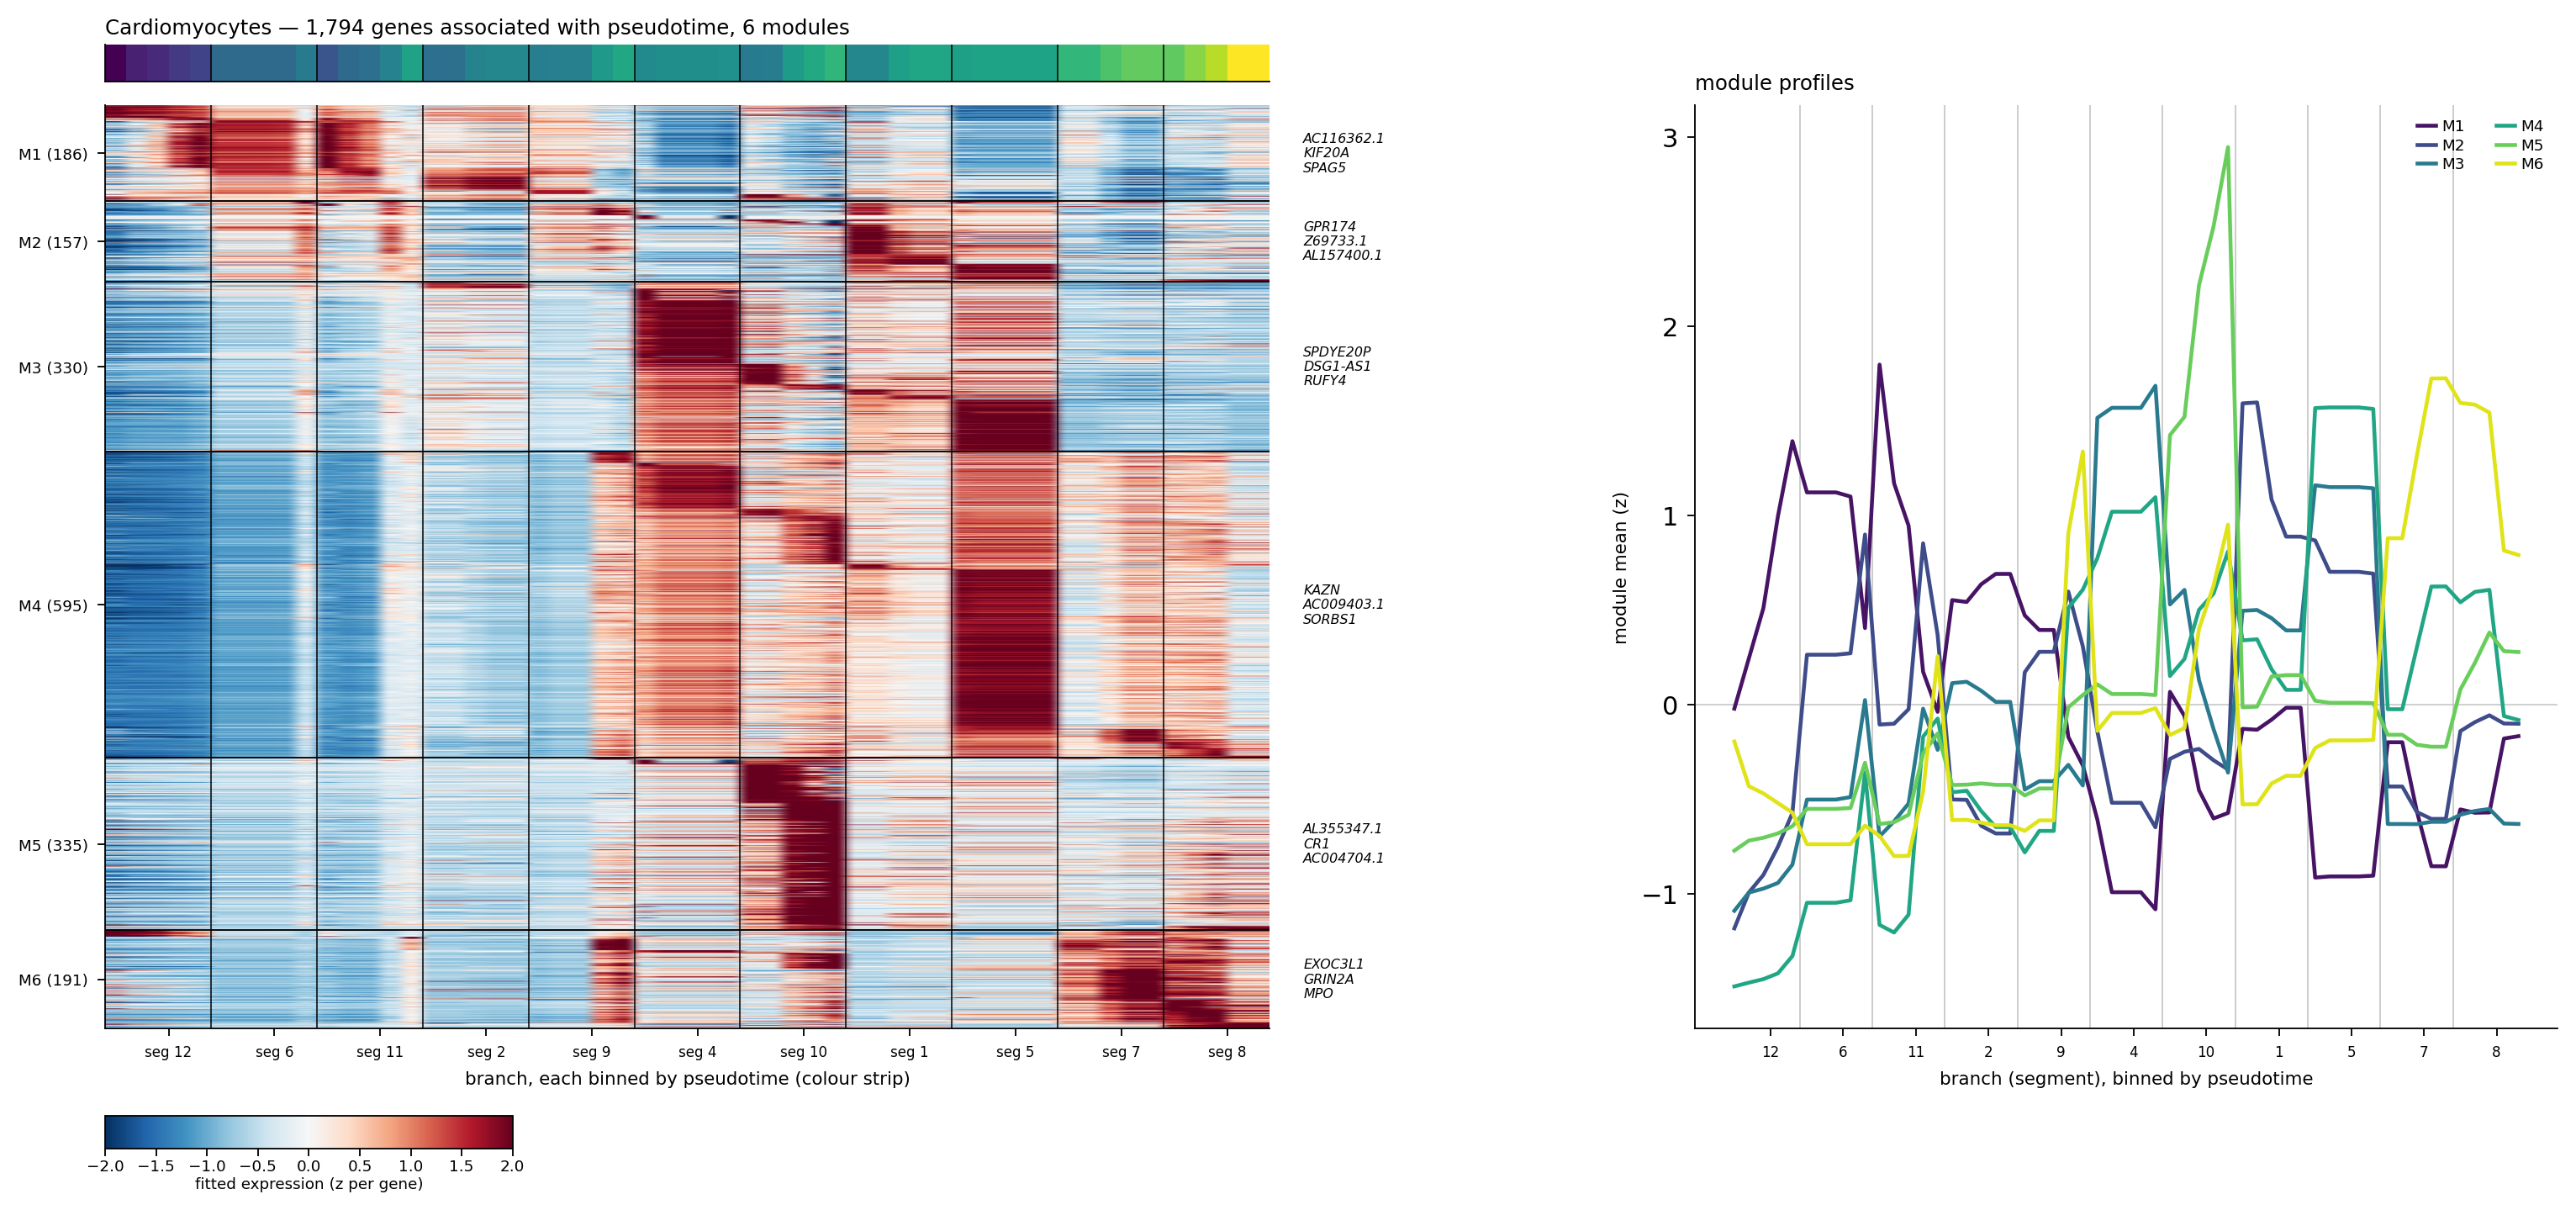

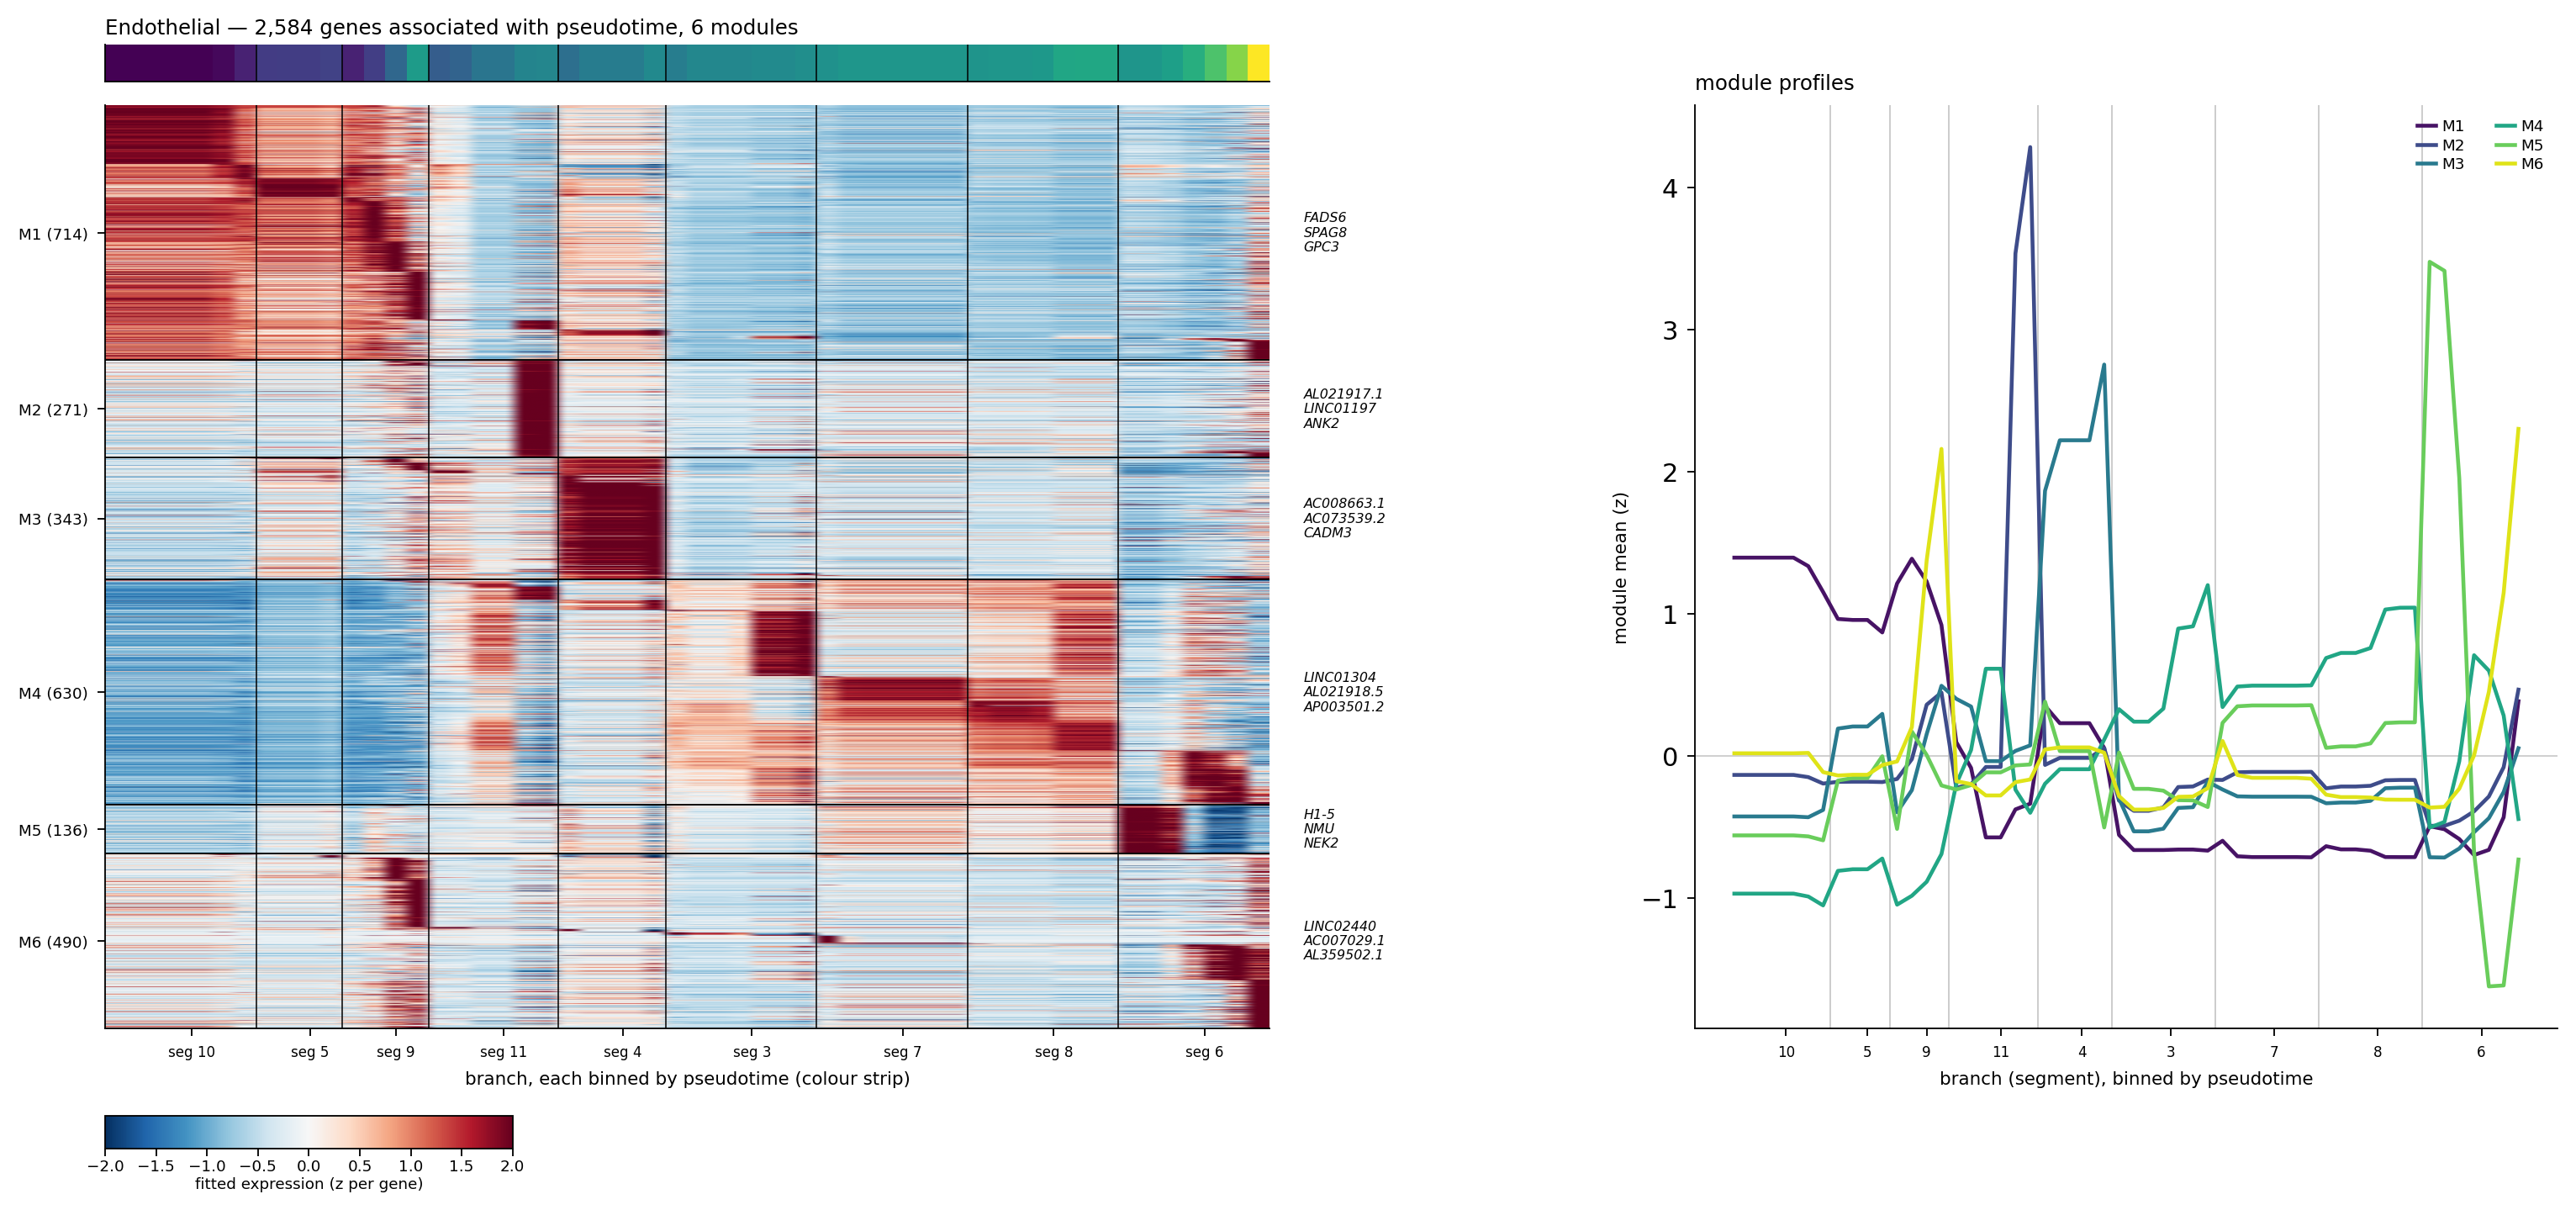

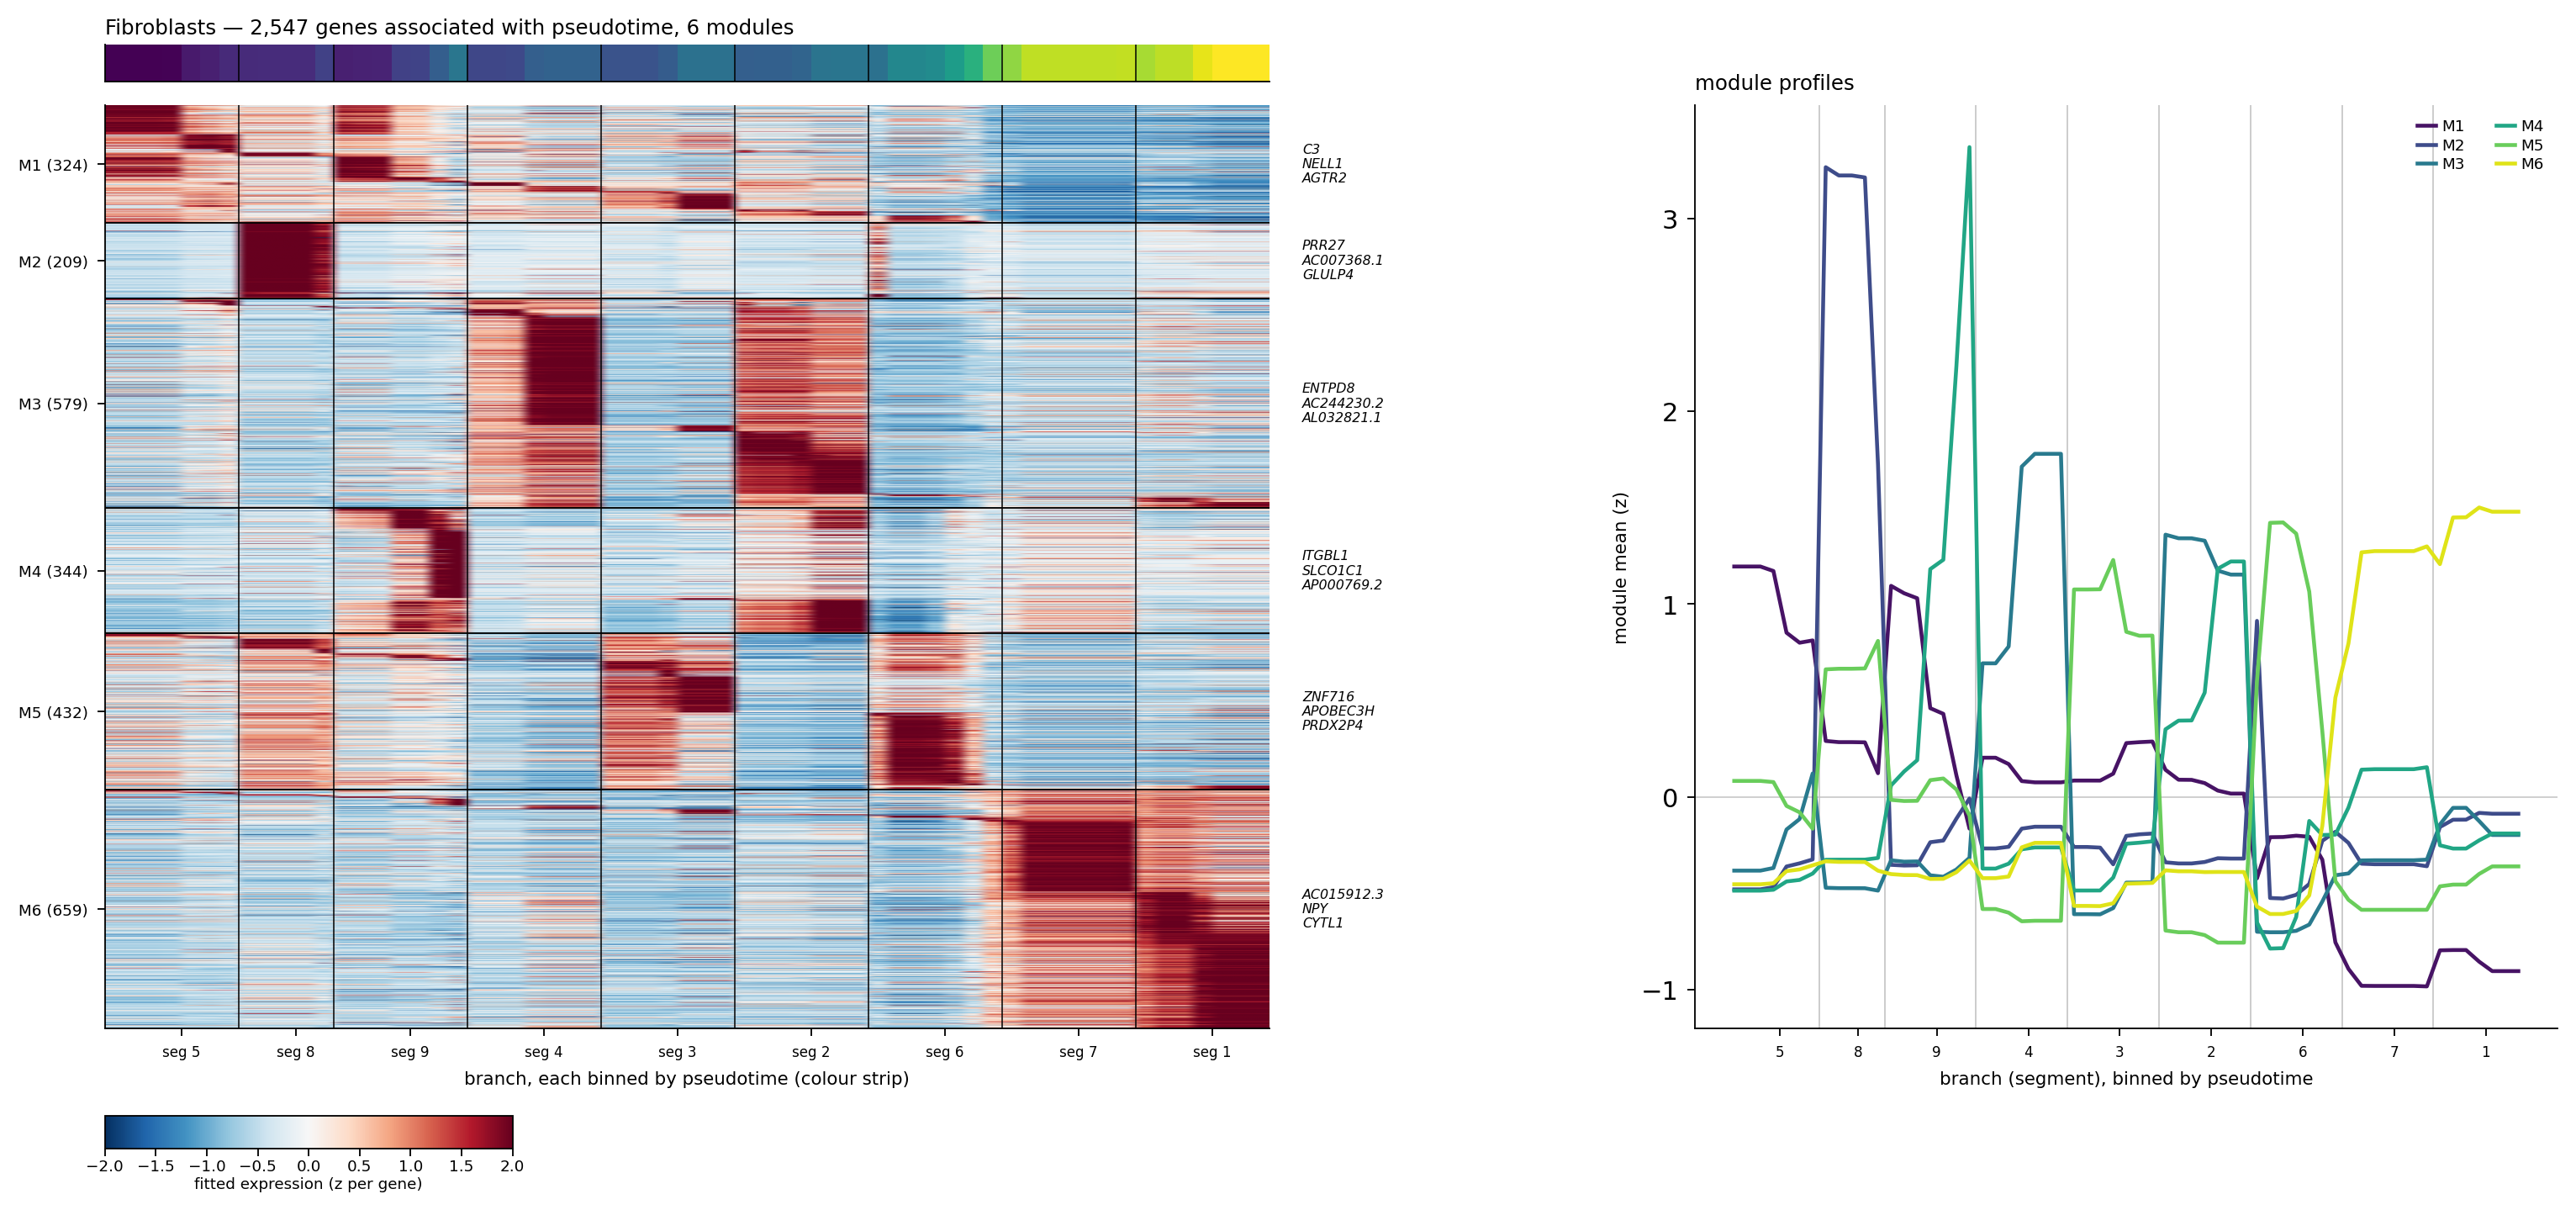

In [ ]:
lista = [("cardiomyocytes02", "Cardiomyocytes", "trends_cardiomyocytes02.png"), 
         ("endothelial", "Endothelial", "trends_endothelial.png"), 
         ("fibroblasts", "Fibroblasts", "trends_fibroblasts.png")]

n_jobs = 15

for fname, title, fig_name in lista:
    print(">>>", fname)
    a = load_fitted(fname)

    if a is None:
        a = assemble(root_bundles / fname)

        a = a[~a.obs["cell.types"].astype(str).str.contains("_excl_")].copy()
        a.obs["cell.types"] = a.obs["cell.types"].astype(str).astype("category")

        # 06_3 preprocessing, then a tree on the harmony embedding
        rs.preprocess(a, n_top_genes=5000, n_neighbors=25, layer="counts", copy=False)

        scf.tl.tree(a, Nodes=20, use_rep="X_harmony_subset", ndims_rep=10,
                    method="ppt", ppt_sigma=0.1, ppt_lambda=100, seed=42)
        # root at the progenitor-rich tip, or an internal node for fibroblasts
        scf.tl.root(a, progenitor_tip(a, ("Prol_CM", "Immat_CM"))[0])
        scf.tl.pseudotime(a, n_jobs=n_jobs, n_map=100, seed=42)
        scf.tl.test_association(a, n_jobs=n_jobs, fdr_cut=1e-4, A_cut=0.3)
        scf.tl.fit(a, n_jobs=n_jobs)

        save_fitted(a, fname)

    fig = tf.trends_figure(a, title, root_figure / fig_name, k=6, figsize=(17, 7))
